In [2]:
!pip install spicy numpy pandas matplotlib seaborn scipy --quiet
import os
import glob
from collections import defaultdict
from itertools import combinations
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline

# ── Visual style ──
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "sans-serif",
})

# ── Constants ──
LOG_DIR     = "NewLogsAnonymized"
PLOT_DIR    = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

TYPE_MAP    = {"HH": "HH", "HVL": "HL", "LVH": "LH", "LVL": "LL"}
TYPE_ORDER  = ["HH", "HL", "LH", "LL"]
VOICE_ORDER = ["Active", "Passive"]
COND_ORDER  = [f"{t}_{v}" for t in TYPE_ORDER for v in VOICE_ORDER]

TYPE_PALETTE  = {"HH": "#2196F3", "HL": "#FF9800", "LH": "#4CAF50", "LL": "#E64A19"}
VOICE_PALETTE = {"Active": "#1565C0", "Passive": "#C62828"}
COND_PALETTE  = {
    "HH_Active": "#1976D2", "HH_Passive": "#64B5F6",
    "HL_Active": "#E65100", "HL_Passive": "#FFB74D",
    "LH_Active": "#2E7D32", "LH_Passive": "#81C784",
    "LL_Active": "#BF360C", "LL_Passive": "#FF8A65",
}

def mean_ci(series, confidence=0.95):
    """Return (mean, 95% CI half-width)."""
    n = len(series)
    m = series.mean()
    if n < 2:
        return m, 0
    se = series.sem()
    ci = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return m, ci

print("✅ Libraries loaded and configuration set.")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✅ Libraries loaded and configuration set.


In [3]:
# ── Load all log files into an IMMUTABLE raw dataframe ──
frames = []
for fp in sorted(glob.glob(os.path.join(LOG_DIR, "*.log"))):
    frames.append(pd.read_csv(fp, na_values=["N/A", ""]))

df_raw = pd.concat(frames, ignore_index=True)      # ← original, NEVER modified
df_raw.columns = df_raw.columns.str.strip()

print(f"Rows loaded       : {len(df_raw):,}")
print(f"Participants found : {df_raw['participant_ID'].nunique()}")
print(f"\n✅ Original dataset stored in  df_raw  — this will NOT be modified.")
print(f"   All transformations happen on a working copy (df).")
df_raw.head(5)

Rows loaded       : 81,329
Participants found : 114

✅ Original dataset stored in  df_raw  — this will NOT be modified.
   All transformations happen on a working copy (df).


,participant_ID,Timestamp,Event,Stimulus,isTarget,isValidation,isRepeat,Button,Accuracy IR,Accuracy WR,Reaction_time_IR,Reaction_time_WR,CR_IR,CR_WR
0,232,1770218920752,Practice Sentence shown,HH_112_A,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,232,1770218923564,Practice IR pressed,HH_112_A,True,NaN,NaN,Spacebar,0.0,NaN,2812.0,NaN,NaN,NaN
2,232,1770218924911,Practice Sentence shown,HL_16_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,232,1770218930413,Practice Sentence shown,HH_116_A,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,232,1770218935915,Practice Sentence shown,HL_62_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ══════════════════════════════════════════════════════════════════════
# STEP A — Create a WORKING COPY and parse (original df_raw untouched)
# ══════════════════════════════════════════════════════════════════════
df = df_raw.copy()

# Boolean columns
for c in ("isTarget", "isValidation", "isRepeat"):
    df[c] = df[c].map({"true": True, True: True}).fillna(False)

# Numeric columns
for c in ("Accuracy IR", "Accuracy WR", "Reaction_time_IR", "Reaction_time_WR"):
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Parse stimulus codes
def parse_stimulus(stim):
    if pd.isna(stim):
        return None, None, None
    parts = stim.split("_")
    if len(parts) < 3:
        return None, None, None
    raw_type, sid, vcode = parts[0], parts[1], parts[2]
    stype = TYPE_MAP.get(raw_type)
    voice = {"A": "Active", "P": "Passive"}.get(vcode)
    return stype, sid, voice

parsed = df["Stimulus"].apply(parse_stimulus)
df["sent_type"] = [p[0] for p in parsed]
df["sent_id"]   = [p[1] for p in parsed]
df["voice"]     = [p[2] for p in parsed]

# ══════════════════════════════════════════════════════════════════════
# STEP B — Assign blocks  (practice = -1, experimental = 1, 2, 3)
# ══════════════════════════════════════════════════════════════════════
block_col = []
for _, grp in df.groupby("participant_ID", sort=False):
    blk = -1
    practice_done = False
    for ev in grp["Event"].values:
        if isinstance(ev, str) and ev.startswith("Practice"):
            block_col.append(-1)
            continue
        if not practice_done:
            practice_done = True
            blk = 1
        if isinstance(ev, str) and ev == "Rest Phase started":
            block_col.append(blk)
            blk += 1
            continue
        block_col.append(blk)

df["block"] = block_col
df_main = df[df["block"] > 0].copy()   # drop practice rows

def validate_block(bdf):
    """Apply the exclusion formula to one participant-block."""
    correct_val_ir = (bdf["Event"] == "Validation IR pressed").sum()
    wrong_ir       = (bdf["Event"] == "Validation Wrong IR pressed").sum()

    # Missed = validation repeats that were shown but never correctly detected
    val_repeats_shown = (
        (bdf["Event"] == "Sentence shown") &
        (bdf["isValidation"] == True) &
        (bdf["isRepeat"] == True)
    ).sum()
    missed_val_ir = max(0, val_repeats_shown - correct_val_ir)

    passes = correct_val_ir > (wrong_ir / 2) + missed_val_ir
    return passes, correct_val_ir, wrong_ir, missed_val_ir

validity_records = []
for (pid, blk), bdf in df_main.groupby(["participant_ID", "block"]):
    ok, c, w, m = validate_block(bdf)
    validity_records.append({
        "participant_ID": pid, "block": blk,
        "valid": ok,
        "correct_val_IRs": c, "wrong_IRs": w, "missed_val_IRs": m,
        "formula_LHS": c,
        "formula_RHS": (w / 2) + m,
    })

val_df = pd.DataFrame(validity_records)

# Tag each row in df_main with its block's validity (without altering df_raw)
df_main = df_main.merge(val_df[["participant_ID", "block", "valid"]],
                        on=["participant_ID", "block"], how="left")

# ══════════════════════════════════════════════════════════════════════
# STEP D — Filter to valid blocks only
# ══════════════════════════════════════════════════════════════════════
df_valid = df_main[df_main["valid"] == True].copy()

total_blocks    = len(val_df)
excluded_blocks = (~val_df["valid"]).sum()
valid_blocks    = total_blocks - excluded_blocks
parts_with_any  = val_df.groupby("participant_ID")["valid"].any()
excluded_parts  = (~parts_with_any).sum()
total_parts     = df["participant_ID"].nunique()

print("=" * 55)
print("  EXCLUSION CRITERIA RESULTS")
print("=" * 55)
print(f"  Original df_raw shape      : {df_raw.shape}  (UNCHANGED)")
print(f"  Working copy rows (no prac): {len(df_main):,}")
print(f"  ─────────────────────────────────────────────")
print(f"  Total participant-blocks   : {total_blocks}")
print(f"  ✅ Valid blocks             : {valid_blocks}  ({100*valid_blocks/total_blocks:.1f}%)")
print(f"  ❌ Excluded blocks          : {excluded_blocks}  ({100*excluded_blocks/total_blocks:.1f}%)")
print(f"  ─────────────────────────────────────────────")
print(f"  Total participants         : {total_parts}")
print(f"  Fully excluded (all blocks): {excluded_parts}")
print(f"  Remaining valid rows       : {len(df_valid):,}")
print("=" * 55)

  EXCLUSION CRITERIA RESULTS
  Original df_raw shape      : (81329, 14)  (UNCHANGED)
  Working copy rows (no prac): 76,060
  ─────────────────────────────────────────────
  Total participant-blocks   : 342
  ✅ Valid blocks             : 329  (96.2%)
  ❌ Excluded blocks          : 13  (3.8%)
  ─────────────────────────────────────────────
  Total participants         : 114
  Fully excluded (all blocks): 2
  Remaining valid rows       : 72,844


In [5]:
# Show the excluded blocks with formula components
excluded_df = val_df[~val_df["valid"]].copy()
excluded_df["formula"] = (
    excluded_df.apply(
        lambda r: f"{r['correct_val_IRs']}  >  ({r['wrong_IRs']}/2) + {r['missed_val_IRs']}  =  {r['formula_RHS']:.1f}  →  FAIL",
        axis=1
    )
)
print(f"❌  {len(excluded_df)} block(s) excluded:\n")
display(excluded_df[["participant_ID", "block",
                     "correct_val_IRs", "wrong_IRs", "missed_val_IRs",
                     "formula_LHS", "formula_RHS", "formula"]]
        .rename(columns={"correct_val_IRs": "Correct Val IRs",
                         "wrong_IRs": "Wrong IRs",
                         "missed_val_IRs": "Missed Val IRs",
                         "formula_LHS": "LHS",
                         "formula_RHS": "RHS"})
        .reset_index(drop=True)
        .to_string(index=False))

# Confirm original is untouched
print(f"\n✅ Verification: df_raw shape is still {df_raw.shape} — original data unchanged.")

❌  13 block(s) excluded:



' participant_ID  block  Correct Val IRs  Wrong IRs  Missed Val IRs  LHS  RHS                             formula\n            245      1                7         10               3    7  8.0   7  >  (10/2) + 3  =  8.0  →  FAIL\n            258      1                7          8               3    7  7.0    7  >  (8/2) + 3  =  7.0  →  FAIL\n            271      1               10         25               0   10 12.5 10  >  (25/2) + 0  =  12.5  →  FAIL\n            271      2               10         21               0   10 10.5 10  >  (21/2) + 0  =  10.5  →  FAIL\n            271      3               10         27               0   10 13.5 10  >  (27/2) + 0  =  13.5  →  FAIL\n            294      1                9         18               1    9 10.0  9  >  (18/2) + 1  =  10.0  →  FAIL\n            297      2               10         20               0   10 10.0 10  >  (20/2) + 0  =  10.0  →  FAIL\n            299      1                7          9               3    7  7.5    7  >  (


✅ Verification: df_raw shape is still (81329, 14) — original data unchanged.


In [6]:
# ── 4a. Overall per participant-block metrics ──
pb_metrics = []
for (pid, blk), g in df_valid.groupby(["participant_ID", "block"]):
    repeats_shown = g[(g["Event"] == "Sentence shown") &
                      (g["isTarget"]) & (g["isRepeat"]) &
                      (g["sent_type"].notna())]
    hits = g[(g["Event"] == "IR pressed") &
             (g["isTarget"]) & (g["isRepeat"]) &
             (g["sent_type"].notna()) & (g["Accuracy IR"] == 1)]
    fa = g[(g["Event"] == "Validation Wrong IR pressed") &
           (g["sent_type"].notna())]
    first_shown = g[(g["Event"] == "Sentence shown") &
                    (g["isTarget"]) & (~g["isRepeat"]) &
                    (g["sent_type"].notna())]

    nr, nh, nf, nfirst = len(repeats_shown), len(hits), len(fa), len(first_shown)
    hr  = nh / nr if nr else 0
    far = nf / nfirst if nfirst else 0
    pb_metrics.append(dict(participant_ID=pid, block=blk,
                           hit_rate=hr, fa_rate=far, corrected=hr - far,
                           n_repeats=nr, n_hits=nh, n_fa=nf, n_first=nfirst))

pb_df = pd.DataFrame(pb_metrics)
overall_far = pb_df["fa_rate"].mean()

# ── 4b. Per condition (type × voice) per participant-block ──
cond_rows = []
for (pid, blk), g in df_valid.groupby(["participant_ID", "block"]):
    far = pb_df.loc[(pb_df["participant_ID"] == pid) &
                    (pb_df["block"] == blk), "fa_rate"].iloc[0]

    for st in TYPE_ORDER:
        for v in VOICE_ORDER:
            shown = g[(g["Event"] == "Sentence shown") &
                      (g["isTarget"]) & (g["isRepeat"]) &
                      (g["sent_type"] == st) & (g["voice"] == v)]
            hits = g[(g["Event"] == "IR pressed") &
                     (g["isTarget"]) & (g["isRepeat"]) &
                     (g["sent_type"] == st) & (g["voice"] == v) &
                     (g["Accuracy IR"] == 1)]
            wr = g[(g["Event"] == "WR pressed") &
                   (g["isTarget"]) & (g["isRepeat"]) &
                   (g["sent_type"] == st) & (g["voice"] == v)]
            rt = g[(g["Event"] == "IR pressed") &
                   (g["isTarget"]) & (g["isRepeat"]) &
                   (g["sent_type"] == st) & (g["voice"] == v) &
                   (g["Accuracy IR"] == 1)]["Reaction_time_IR"].dropna()

            ns = len(shown)
            if ns == 0:
                continue
            hr = len(hits) / ns
            wr_acc = wr["Accuracy WR"].mean() if len(wr) else np.nan
            mean_rt = rt.mean() if len(rt) else np.nan

            cond_rows.append(dict(
                participant_ID=pid, block=blk,
                sent_type=st, voice=v, condition=f"{st}_{v}",
                hit_rate=hr, fa_rate=far, corrected=hr - far,
                wr_accuracy=wr_acc, mean_rt_ir=mean_rt,
                n_shown=ns, n_hits=len(hits)))

cond_df = pd.DataFrame(cond_rows)

# ── Add Subject / Object memorability labels ──
subj_obj = {"HH": ("High", "High"), "HL": ("High", "Low"),
            "LH": ("Low", "High"),  "LL": ("Low", "Low")}
cond_df["subject_mem"] = cond_df["sent_type"].map(lambda t: subj_obj.get(t, (None, None))[0])
cond_df["object_mem"]  = cond_df["sent_type"].map(lambda t: subj_obj.get(t, (None, None))[1])

# ── 4c. Per-sentence memorability ──
sent_rows = []
target_repeat_shown = df_valid[(df_valid["Event"] == "Sentence shown") &
                               (df_valid["isTarget"]) & (df_valid["isRepeat"]) &
                               (df_valid["sent_type"].notna())]
target_ir = df_valid[(df_valid["Event"] == "IR pressed") &
                     (df_valid["isTarget"]) & (df_valid["isRepeat"]) &
                     (df_valid["sent_type"].notna())]

for (st, sid, v), grp_shown in target_repeat_shown.groupby(
        ["sent_type", "sent_id", "voice"]):
    n_total = len(grp_shown)
    grp_hits = target_ir[(target_ir["sent_type"] == st) &
                         (target_ir["sent_id"] == sid) &
                         (target_ir["voice"] == v) &
                         (target_ir["Accuracy IR"] == 1)]
    n_hits = len(grp_hits)
    hr = n_hits / n_total if n_total else 0
    sent_rows.append(dict(sent_type=st, sent_id=sid, voice=v,
                          condition=f"{st}_{v}",
                          hit_rate=hr, corrected=hr - overall_far,
                          n_presentations=n_total, n_hits=n_hits))

sent_df = pd.DataFrame(sent_rows)

print(f"Valid participant-blocks : {len(pb_df)}")
print(f"Condition-level obs     : {len(cond_df)}")
print(f"Unique sentences        : {len(sent_df)}")
print(f"Overall mean FAR        : {overall_far:.3f}")
print(f"Overall mean HR         : {pb_df['hit_rate'].mean():.3f}")
print(f"Overall corrected score : {pb_df['corrected'].mean():.3f}")

Valid participant-blocks : 329
Condition-level obs     : 2632
Unique sentences        : 392
Overall mean FAR        : 0.021
Overall mean HR         : 0.833
Overall corrected score : 0.812


  SDT SUMMARY  —  participant-block level
      dprime  criterion
mean   2.951      0.432
std    0.644      0.378

  SDT SUMMARY  —  by condition (type × voice)
                  dprime        criterion       
                    mean    std      mean    std
sent_type voice                                 
HH        Active   2.569  0.607     0.623  0.336
          Passive  2.602  0.616     0.607  0.308
HL        Active   2.581  0.566     0.617  0.324
          Passive  2.590  0.580     0.613  0.324
LH        Active   2.560  0.587     0.627  0.329
          Passive  2.569  0.599     0.623  0.331
LL        Active   2.460  0.642     0.677  0.348
          Passive  2.481  0.640     0.667  0.370


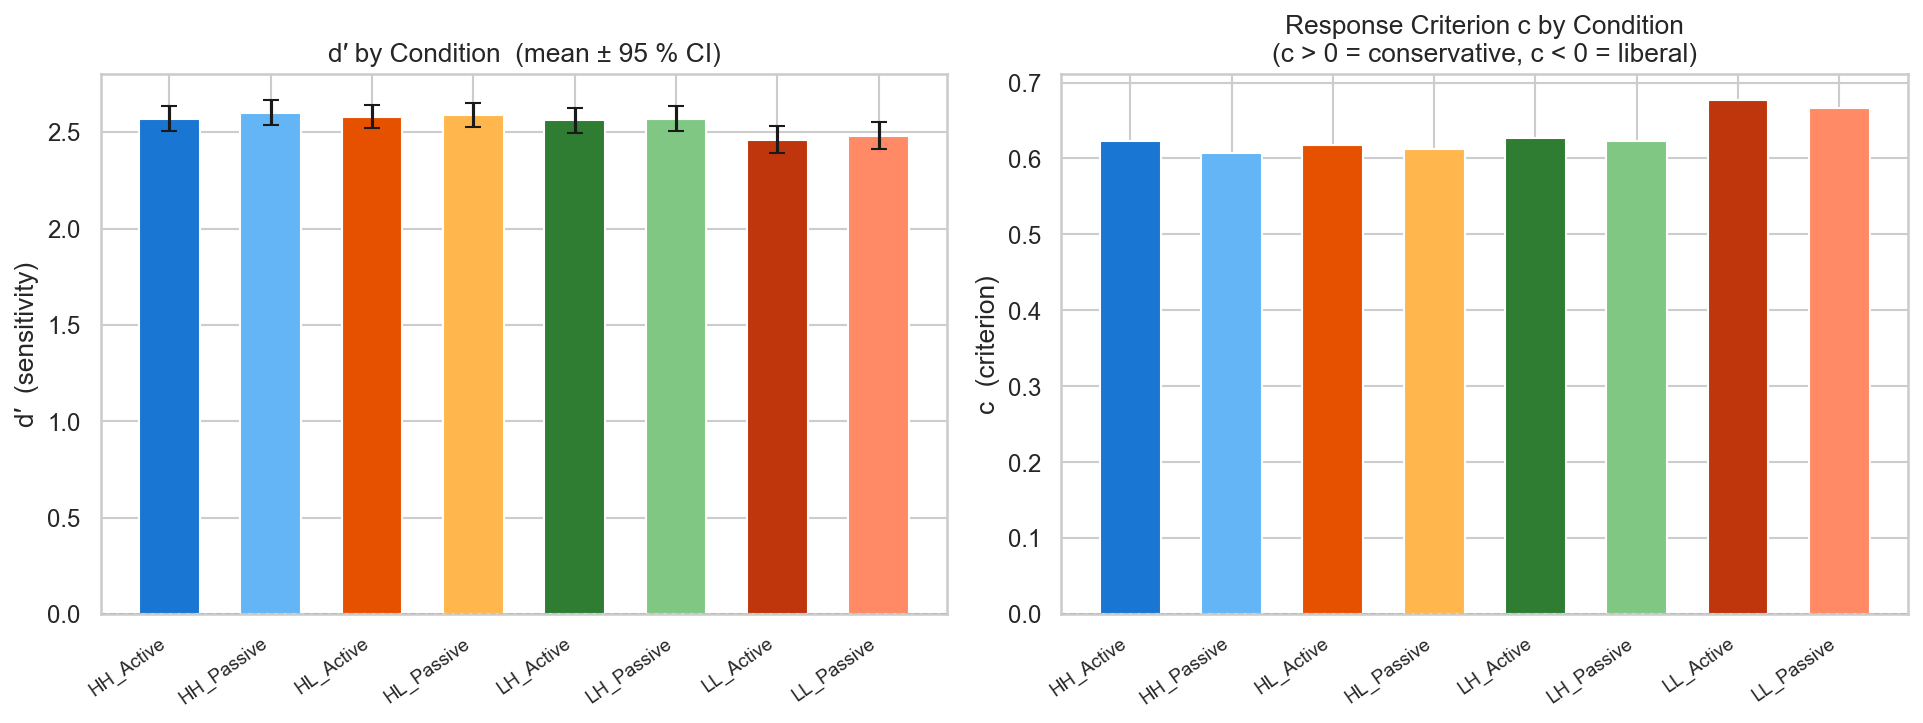

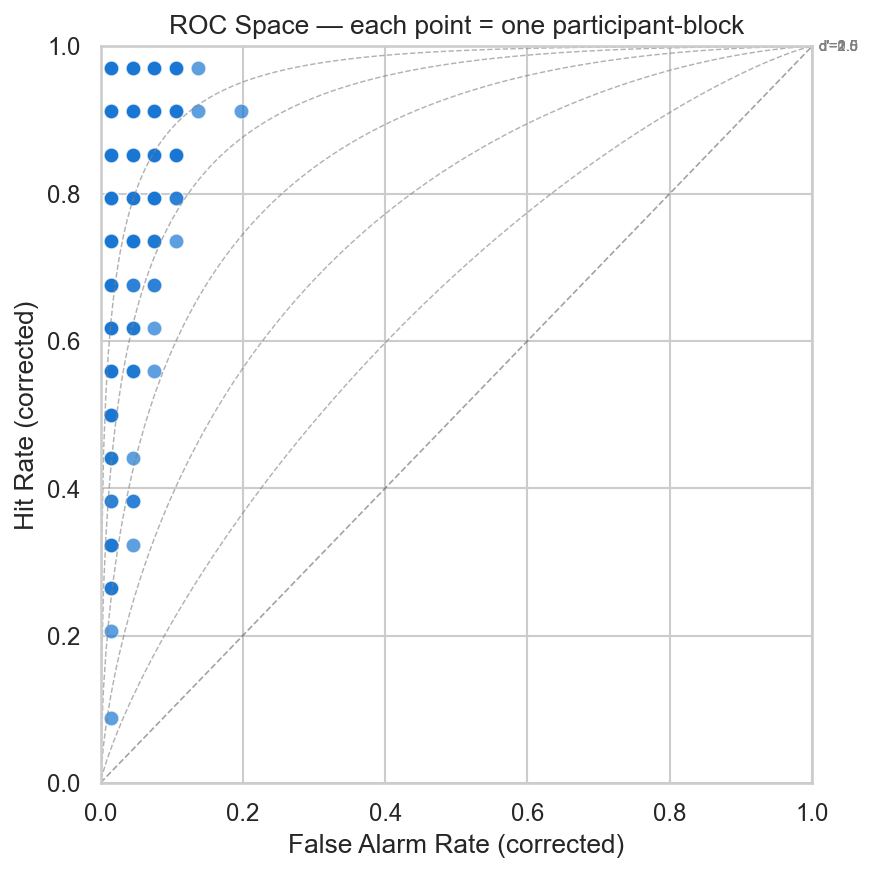


✅  SDT columns added to  pb_df  (dprime, criterion, hr_corr, far_corr)
   SDT columns added to  cond_df (dprime, criterion)


In [7]:
# ══════════════════════════════════════════════════════════════════════
# SIGNAL DETECTION THEORY  —  d' (sensitivity) and c (criterion)
# ══════════════════════════════════════════════════════════════════════
# Formulas
#   d' = z(HR) – z(FAR)          ← distance between old/new distributions
#   c  = –0.5 · [z(HR) + z(FAR)] ← response criterion (0 = unbiased)
#
# Extreme-value correction (Hautus 1995 log-linear rule):
#   HR_corr  = (n_hits + 0.5) / (n_signal + 1)
#   FAR_corr = (n_fa   + 0.5) / (n_noise  + 1)
# This avoids z(0) = –∞ and z(1) = +∞ without discarding any data.
# ══════════════════════════════════════════════════════════════════════

from scipy.stats import norm as _norm

def _corr(n_hits, n_signal, n_fa, n_noise):
    """Log-linear correction → corrected HR and FAR."""
    hr  = (n_hits + 0.5) / (n_signal + 1)
    far = (n_fa   + 0.5) / (n_noise  + 1)
    return hr, far

def _sdt(hr_c, far_c):
    """d' and c from corrected rates."""
    zh = _norm.ppf(hr_c)
    zf = _norm.ppf(far_c)
    return zh - zf, -0.5 * (zh + zf)

# ── Level 1: participant-block ──────────────────────────────────────
sdt_pb = []
for _, row in pb_df.iterrows():
    hr_c, far_c = _corr(row["n_hits"], row["n_repeats"],
                        row["n_fa"],  row["n_first"])
    d, c = _sdt(hr_c, far_c)
    sdt_pb.append({"participant_ID": row["participant_ID"],
                   "block": row["block"],
                   "dprime": d, "criterion": c,
                   "hr_corr": hr_c, "far_corr": far_c})

sdt_pb_df = pd.DataFrame(sdt_pb)
pb_df = pb_df.merge(sdt_pb_df, on=["participant_ID", "block"], how="left")

# ── Level 2: condition (type × voice) per participant-block ─────────
# FAR is block-level (not condition-specific), so we pull n_fa / n_first
# from pb_df and use condition-level n_hits / n_shown for HR.
pb_lookup = pb_df.set_index(["participant_ID", "block"])[["n_fa", "n_first"]]

sdt_cond = []
for _, row in cond_df.iterrows():
    n_fa_blk, n_first_blk = pb_lookup.loc[
        (row["participant_ID"], row["block"]), ["n_fa", "n_first"]]
    hr_c, far_c = _corr(row["n_hits"], row["n_shown"],
                        n_fa_blk, n_first_blk)
    d, c = _sdt(hr_c, far_c)
    sdt_cond.append({"participant_ID": row["participant_ID"],
                     "block": row["block"],
                     "sent_type": row["sent_type"],
                     "voice": row["voice"],
                     "dprime": d, "criterion": c})

sdt_cond_df = pd.DataFrame(sdt_cond)
cond_df = cond_df.merge(sdt_cond_df,
                        on=["participant_ID", "block", "sent_type", "voice"],
                        how="left")

# ── Summary tables ──────────────────────────────────────────────────
print("=" * 55)
print("  SDT SUMMARY  —  participant-block level")
print("=" * 55)
pb_sdt_summary = pb_df[["dprime", "criterion"]].agg(["mean", "std"])
print(pb_sdt_summary.round(3).to_string())

print("\n" + "=" * 55)
print("  SDT SUMMARY  —  by condition (type × voice)")
print("=" * 55)
cond_sdt_summary = (cond_df
    .groupby(["sent_type", "voice"])[["dprime", "criterion"]]
    .agg(["mean", "std"])
    .round(3))
print(cond_sdt_summary.to_string())

# ── Plot 1: d' by condition ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: mean d' per condition
cond_means = (cond_df
    .groupby(["sent_type", "voice"])["dprime"]
    .agg(["mean", "sem"])
    .reset_index())
cond_means["condition"] = cond_means["sent_type"] + "_" + cond_means["voice"]

ax = axes[0]
bars = ax.bar(range(len(cond_means)),
              cond_means["mean"],
              yerr=cond_means["sem"] * 1.96,
              color=[COND_PALETTE.get(c, "#888") for c in cond_means["condition"]],
              capsize=4, width=0.6, edgecolor="white")
ax.set_xticks(range(len(cond_means)))
ax.set_xticklabels(cond_means["condition"], rotation=35, ha="right", fontsize=9)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_ylabel("d′  (sensitivity)")
ax.set_title("d′ by Condition  (mean ± 95 % CI)")

# Bar chart: mean criterion c per condition
ax = axes[1]
ax.bar(range(len(cond_means)),
       cond_df.groupby(["sent_type", "voice"])["criterion"].mean().values,
       color=[COND_PALETTE.get(c, "#888") for c in cond_means["condition"]],
       width=0.6, edgecolor="white")
ax.set_xticks(range(len(cond_means)))
ax.set_xticklabels(cond_means["condition"], rotation=35, ha="right", fontsize=9)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_ylabel("c  (criterion)")
ax.set_title("Response Criterion c by Condition\n"
             "(c > 0 = conservative, c < 0 = liberal)")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/sdt_by_condition.png", bbox_inches="tight")
plt.show()

# ── Plot 2: ROC space (FAR vs HR per participant-block) ─────────────
fig, ax = plt.subplots(figsize=(6, 6))

# d' iso-lines
for dp in [0.5, 1.0, 1.5, 2.0, 2.5]:
    far_range = np.linspace(0.001, 0.999, 300)
    hr_iso    = _norm.cdf(_norm.ppf(far_range) + dp)
    ax.plot(far_range, hr_iso, color="grey", linewidth=0.7,
            linestyle="--", alpha=0.6)
    ax.text(far_range[-1] + 0.01, hr_iso[-1], f"d′={dp}", fontsize=7,
            color="grey", va="center")

ax.scatter(pb_df["far_corr"], pb_df["hr_corr"],
           alpha=0.7, s=50, color="#1976D2", edgecolors="white", linewidths=0.5)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4)   # chance line
ax.set_xlabel("False Alarm Rate (corrected)")
ax.set_ylabel("Hit Rate (corrected)")
ax.set_title("ROC Space — each point = one participant-block")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/sdt_roc_space.png", bbox_inches="tight")
plt.show()

print("\n✅  SDT columns added to  pb_df  (dprime, criterion, hr_corr, far_corr)")
print("   SDT columns added to  cond_df (dprime, criterion)")


# Hypothesis 1: Accuracy Increases Over Time (Blocks 1 → 2 → 3)

## Rationale
If participants consolidate sentence memory over the session, hit rate and d′ should rise monotonically from Block 1 to Block 3. This is a within-subjects design — each participant contributes one observation per block.

## Pipeline
| Step | Action |
|------|--------|
| 1 | Restrict to **complete cases** (valid data in all 3 blocks) |
| 2 | Descriptive statistics + visualisation |
| 3 | **Shapiro–Wilk** normality test on each block and pairwise difference scores |
| 4 | **Main test** — RM-ANOVA (normal) or Friedman χ² (non-normal) |
| 5 | **Post-hoc** — paired *t* or Wilcoxon signed-rank, Bonferroni-corrected (α/3 = 0.0167) |
| 6 | Stratified by **sentence type** (HH, HL, LH, LL) |

All tests two-tailed, α = 0.05.


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  COMPLETE-CASE SUMMARY
  Participants with ≥1 valid block : 112
  Complete cases (all 3 blocks)    : 105
  Rows used for RM tests           : 315

Hit Rate by Block:
         n    mean      sd     sem  95%_CI
block                                     
1      105  0.8560  0.1390  0.0136  0.0266
2      105  0.8363  0.1785  0.0174  0.0342
3      105  0.8101  0.1793  0.0175  0.0343

d′ by Block:
         n    mean      sd     sem  95%_CI
block                                     
1      105  3.0215  0.5930  0.0579  0.1134
2      105  2.9851  0.6539  0.0638  0.1251
3      105  2.8668  0.6540  0.0638  0.1251


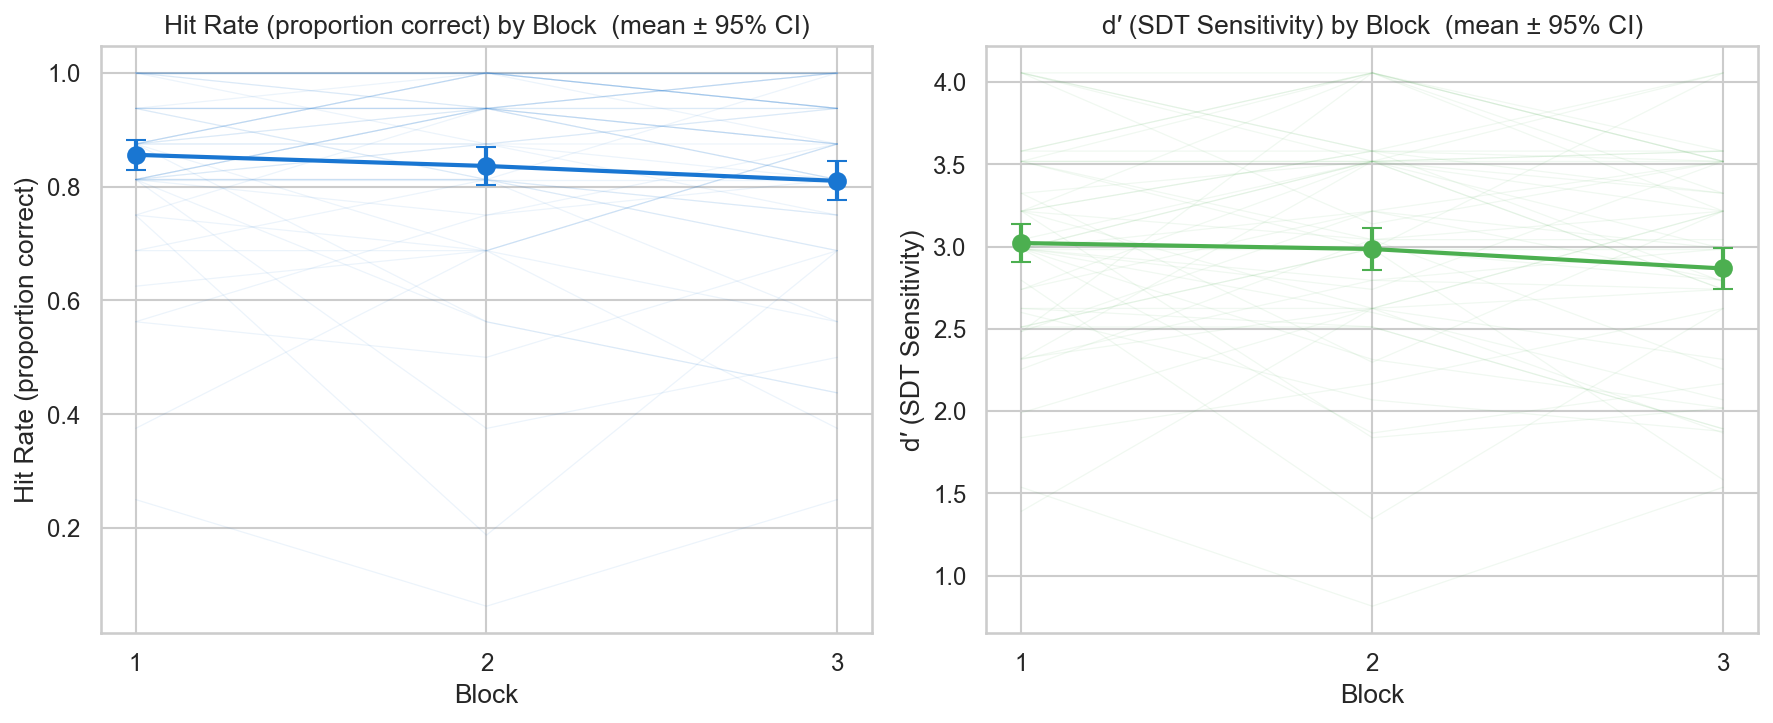

✅  Saved: plots/h1_accuracy_over_blocks.png


In [12]:
!pip install pingouin --quiet

import pingouin as pg
from scipy.stats import shapiro, friedmanchisquare, wilcoxon, ttest_rel, probplot

ALPHA      = 0.05
N_COMP     = 3
ALPHA_BONF = ALPHA / N_COMP

# ── Complete-case participants ───────────────────────────────────────
counts        = pb_df.groupby("participant_ID")["block"].nunique()
complete_pids = counts[counts == 3].index
pb_complete   = pb_df[pb_df["participant_ID"].isin(complete_pids)].copy()

print("=" * 55)
print("  COMPLETE-CASE SUMMARY")
print("=" * 55)
print(f"  Participants with ≥1 valid block : {pb_df['participant_ID'].nunique()}")
print(f"  Complete cases (all 3 blocks)    : {len(complete_pids)}")
print(f"  Rows used for RM tests           : {len(pb_complete)}")

# ── Descriptive statistics ───────────────────────────────────────────
for col, lbl in [("hit_rate", "Hit Rate"), ("dprime", "d′")]:
    desc = pb_complete.groupby("block")[col].agg(n="count", mean="mean", sd="std", sem="sem")
    desc["95%_CI"] = desc["sem"] * 1.96
    print(f"\n{lbl} by Block:\n{desc.round(4).to_string()}")

# ── Line plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, label, color in [
    (axes[0], "hit_rate", "Hit Rate (proportion correct)", "#1976D2"),
    (axes[1], "dprime",   "d′ (SDT Sensitivity)",          "#4CAF50"),
]:
    desc = pb_complete.groupby("block")[metric].agg(mean="mean", sem="sem").reset_index()
    ax.errorbar(desc["block"], desc["mean"], yerr=desc["sem"] * 1.96,
                marker="o", color=color, capsize=5, linewidth=2, markersize=8)
    for pid in complete_pids[:50]:
        p = pb_complete[pb_complete["participant_ID"] == pid].sort_values("block")
        ax.plot(p["block"], p[metric], color=color, alpha=0.08, linewidth=0.6)
    ax.set_xticks([1, 2, 3]); ax.set_xlabel("Block"); ax.set_ylabel(label)
    ax.set_title(f"{label} by Block  (mean ± 95% CI)")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/h1_accuracy_over_blocks.png", bbox_inches="tight")
plt.show()
print("✅  Saved: plots/h1_accuracy_over_blocks.png")

SHAPIRO–WILK NORMALITY TESTS

── Hit Rate ──
    Series   n      W      p Normal?
   Block 1 105 0.8486 0.0000       ❌
   Block 2 105 0.8060 0.0000       ❌
   Block 3 105 0.8661 0.0000       ❌
Diff B2−B1 105 0.9273 0.0000       ❌
Diff B3−B1 105 0.9440 0.0002       ❌
Diff B3−B2 105 0.9470 0.0004       ❌
  → VIOLATION ❌  → use non-parametric

── d′ ──
    Series   n      W      p Normal?
   Block 1 105 0.9685 0.0133       ❌
   Block 2 105 0.9628 0.0048       ❌
   Block 3 105 0.9681 0.0124       ❌
Diff B2−B1 105 0.9841 0.2451       ✅
Diff B3−B1 105 0.9831 0.2044       ✅
Diff B3−B2 105 0.9879 0.4649       ✅
  → VIOLATION ❌  → use non-parametric

  FINAL DECISION: Non-parametric  (Friedman χ² + Wilcoxon)


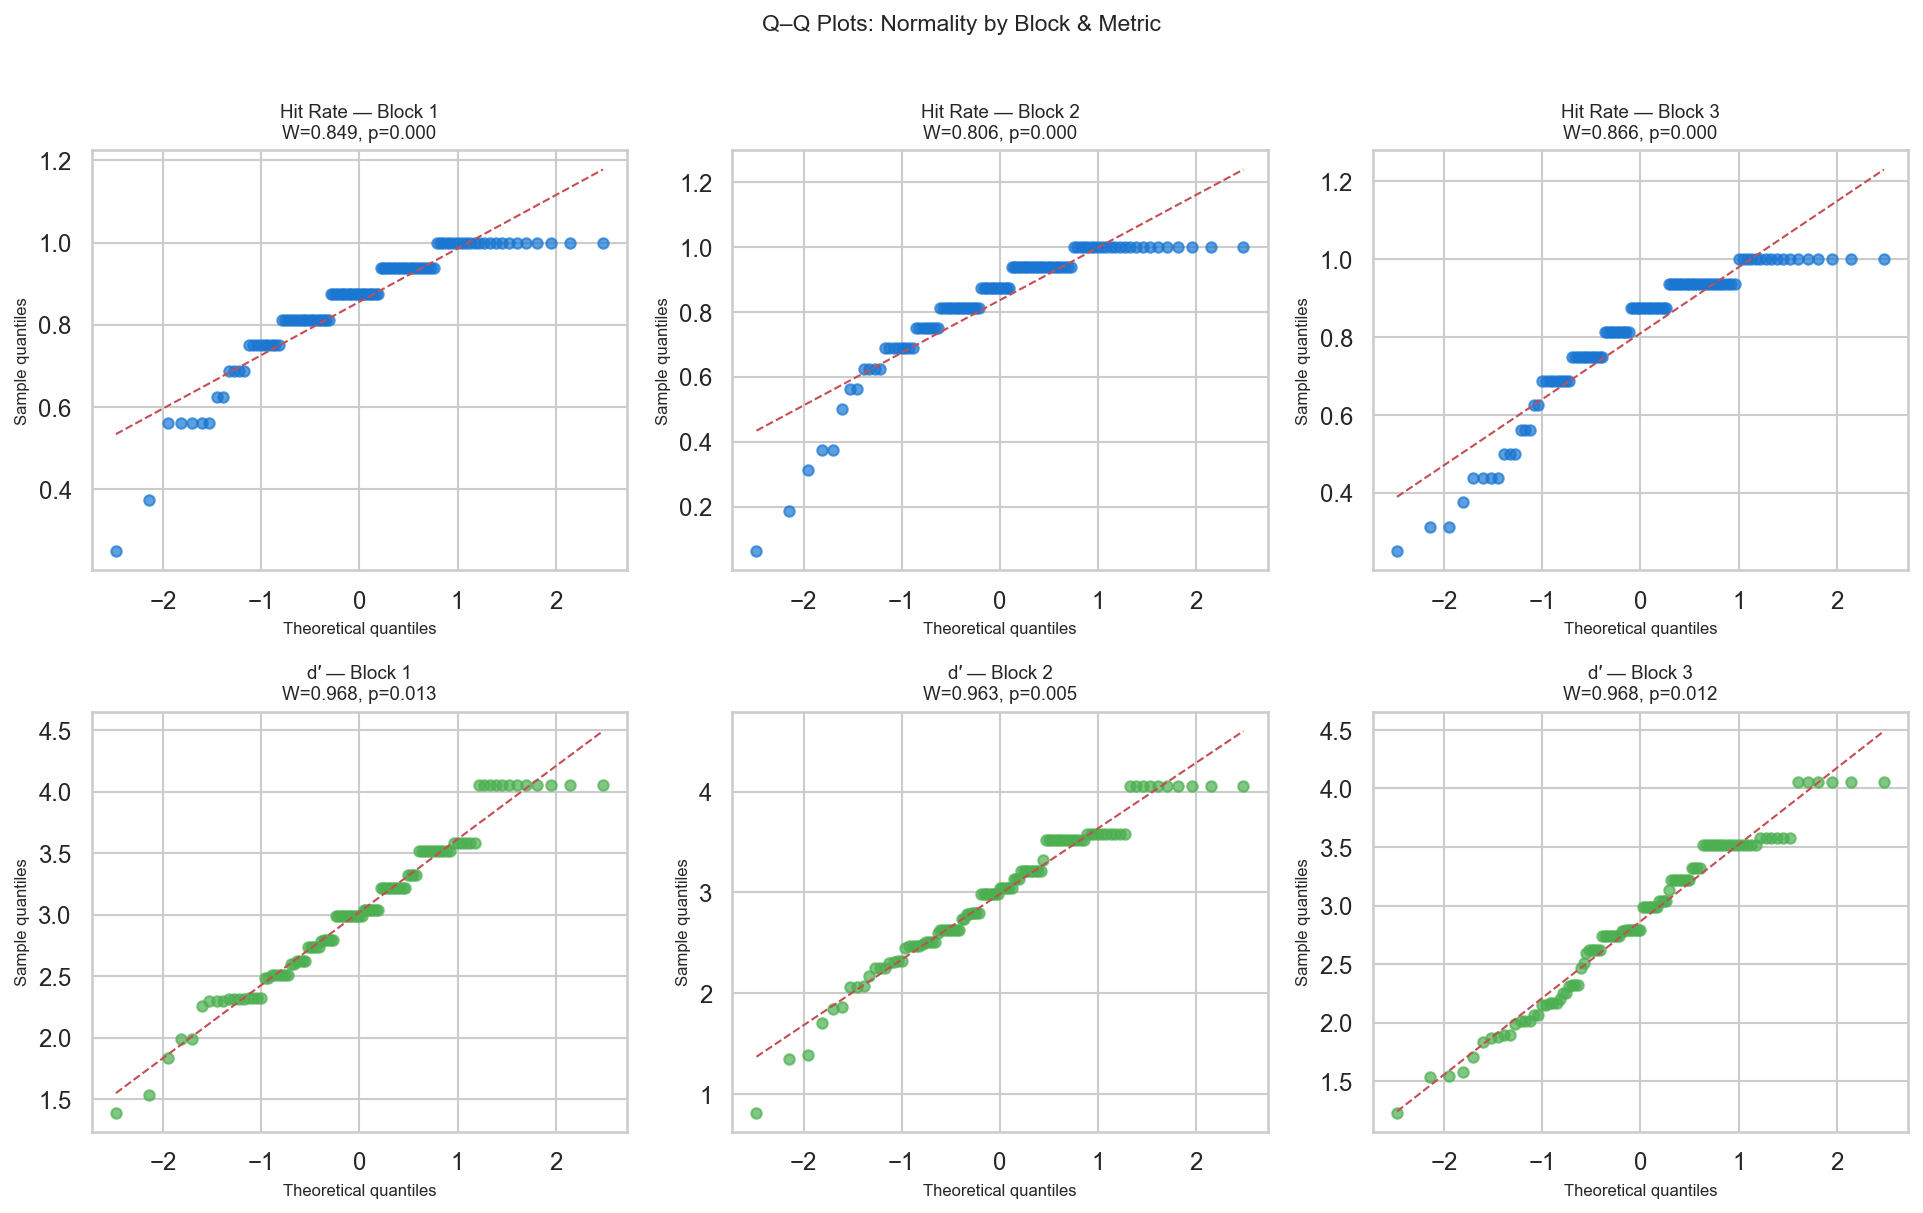

✅  Saved: plots/h1_qq_plots.png


In [13]:
# ── Normality: Shapiro–Wilk on per-block distributions + difference scores ──

wide_hr = pb_complete.pivot(index="participant_ID", columns="block", values="hit_rate")
wide_dp = pb_complete.pivot(index="participant_ID", columns="block", values="dprime")

def shapiro_report(label, wide_data):
    rows, flags = [], {}
    for blk in [1, 2, 3]:
        d = wide_data[blk].dropna()
        W, p = shapiro(d)
        ok = p > ALPHA
        flags[f"b{blk}"] = ok
        rows.append({"Series": f"Block {blk}", "n": len(d), "W": round(W,4), "p": round(p,4),
                     "Normal?": "✅" if ok else "❌"})
    for b1, b2 in [(1,2),(1,3),(2,3)]:
        diff = (wide_data[b2] - wide_data[b1]).dropna()
        W, p = shapiro(diff)
        ok = p > ALPHA
        flags[f"d{b1}{b2}"] = ok
        rows.append({"Series": f"Diff B{b2}−B{b1}", "n": len(diff), "W": round(W,4), "p": round(p,4),
                     "Normal?": "✅" if ok else "❌"})
    all_ok = all(flags.values())
    print(f"\n── {label} ──")
    print(pd.DataFrame(rows).to_string(index=False))
    print(f"  → {'ALL NORMAL ✅' if all_ok else 'VIOLATION ❌  → use non-parametric'}")
    return all_ok

print("SHAPIRO–WILK NORMALITY TESTS")
print("=" * 55)
norm_hr = shapiro_report("Hit Rate", wide_hr)
norm_dp = shapiro_report("d′",       wide_dp)
use_parametric = norm_hr and norm_dp
print(f"\n  FINAL DECISION: {'Parametric  (RM-ANOVA + paired t)' if use_parametric else 'Non-parametric  (Friedman χ² + Wilcoxon)'}")

# ── Q–Q plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ri, (wide_data, label, col) in enumerate([
    (wide_hr, "Hit Rate", "#1976D2"),
    (wide_dp, "d′",       "#4CAF50"),
]):
    for ci, blk in enumerate([1, 2, 3]):
        ax = axes[ri, ci]
        d = wide_data[blk].dropna()
        (osm, osr), (slope, intercept, _) = probplot(d, dist="norm")
        ax.scatter(osm, osr, s=25, alpha=0.7, color=col)
        ax.plot(osm, slope * np.array(osm) + intercept, "r--", linewidth=1)
        W, p = shapiro(d)
        ax.set_title(f"{label} — Block {blk}\nW={W:.3f}, p={p:.3f}", fontsize=9)
        ax.set_xlabel("Theoretical quantiles", fontsize=8)
        ax.set_ylabel("Sample quantiles", fontsize=8)
plt.suptitle("Q–Q Plots: Normality by Block & Metric", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/h1_qq_plots.png", bbox_inches="tight")
plt.show()
print("✅  Saved: plots/h1_qq_plots.png")

## Main Test + Post-hoc (H1 — Accuracy)

| Path | Test | Post-hoc |
|------|------|----------|
| Normal | RM-ANOVA (*pingouin*) | Paired *t*-test, Bonferroni |
| Non-normal | Friedman χ² | Wilcoxon signed-rank, Bonferroni |

Effect sizes: **η²p** (RM-ANOVA) or **Kendall's W** (Friedman).  
Post-hoc α = 0.05 / 3 = **0.0167**.


═══════════════════════════════════════════════════════
  Hit Rate
═══════════════════════════════════════════════════════
  Friedman  chi2(2)=6.5757  p=0.0373  Kendall W=0.0251  significant

  Post-hoc -- Hit Rate  (Bonferroni alpha=0.0167)
  B1->B2: W=1116.500 p_raw=0.2621 p_bonf=0.7864 n.s.  down (0.856->0.836)
  B1->B3: W=1188.500 p_raw=0.0071 p_bonf=0.0212 sig  down (0.856->0.810)
  B2->B3: W=1395.000 p_raw=0.0775 p_bonf=0.2324 n.s.  down (0.836->0.810)

═══════════════════════════════════════════════════════
  d-prime (sensitivity)
═══════════════════════════════════════════════════════
  Friedman  chi2(2)=2.4154  p=0.2989  Kendall W=0.0107  n.s.

  Post-hoc -- d-prime  (Bonferroni alpha=0.0167)
  (main test n.s. -- skipped)


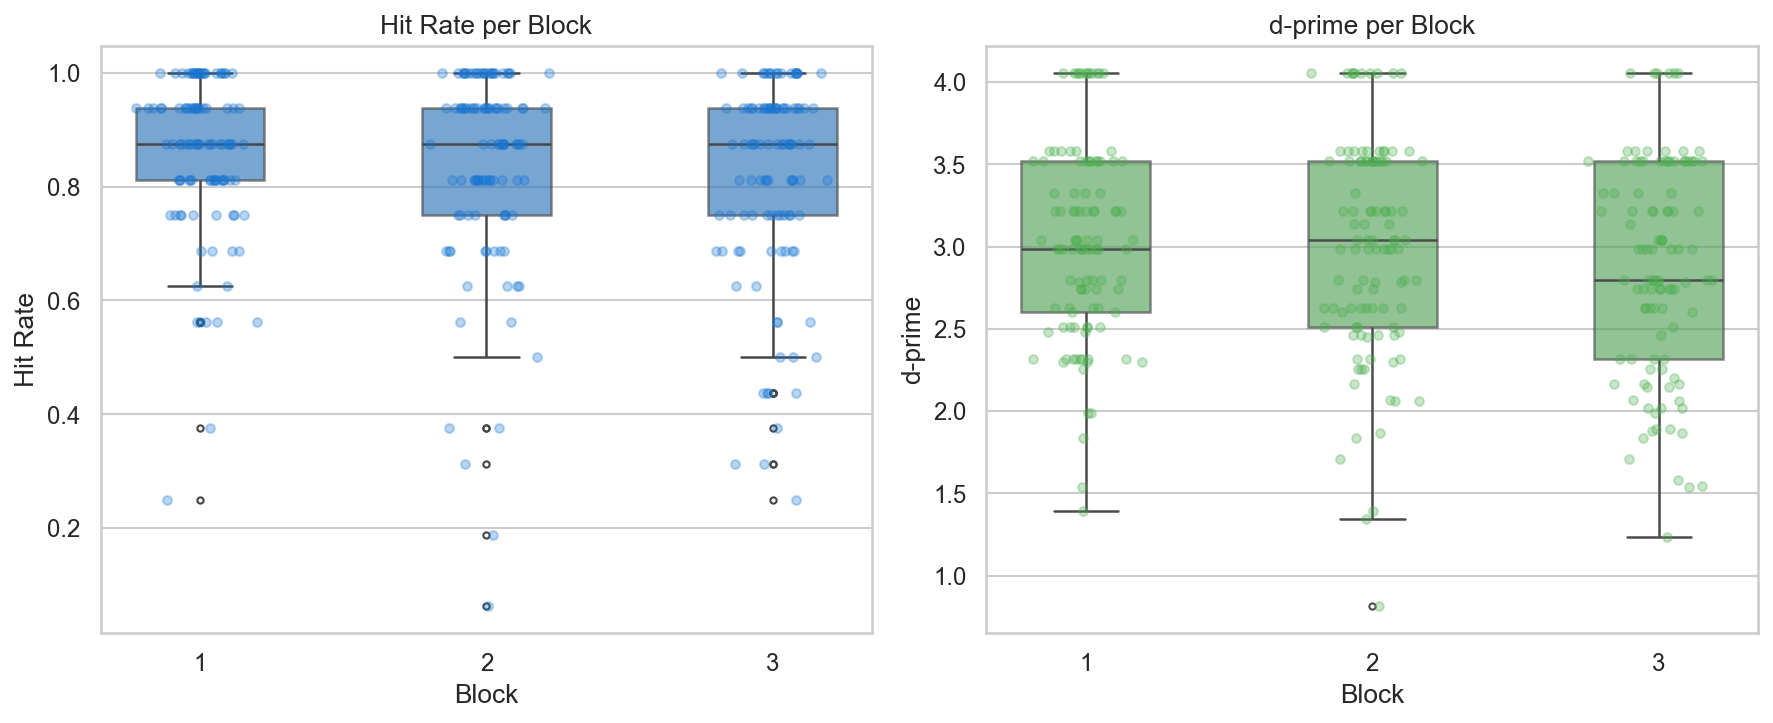


  H1 -- BY SENTENCE TYPE

  HH  n=105  (non-param)
    Hit Rate: chi2=6.361 p=0.0416 W=0.016 sig  B1=0.893 B2=0.848 B3=0.821 (down)
      B1->B2: p_bonf=0.2044 n.s.  (down)
      B1->B3: p_bonf=0.0075 sig  (down)
      B2->B3: p_bonf=0.7185 n.s.  (down)
    d-prime: chi2=5.139 p=0.0766 W=0.020 n.s.  B1=2.672 B2=2.596 B3=2.530 (down)

  HL  n=105  (non-param)
    Hit Rate: chi2=4.114 p=0.1278 W=0.011 n.s.  B1=0.886 B2=0.850 B3=0.814 (down)
    d-prime: chi2=2.619 p=0.2699 W=0.010 n.s.  B1=2.658 B2=2.600 B3=2.516 (down)

  LH  n=105  (non-param)
    Hit Rate: chi2=0.415 p=0.8125 W=0.001 n.s.  B1=0.836 B2=0.848 B3=0.843 (up)
    d-prime: chi2=1.994 p=0.3689 W=0.008 n.s.  B1=2.561 B2=2.596 B3=2.572 (up)

  LL  n=105  (non-param)
    Hit Rate: chi2=4.782 p=0.0916 W=0.014 n.s.  B1=0.810 B2=0.800 B3=0.762 (down)
    d-prime: chi2=3.107 p=0.2115 W=0.013 n.s.  B1=2.510 B2=2.503 B3=2.415 (down)

[H1 complete]


In [ ]:
def kendall_w(mat):
    n, k = mat.shape
    ranks = np.apply_along_axis(lambda x: stats.rankdata(x), 1, mat)
    R = ranks.sum(axis=0);  S = ((R - R.mean()) ** 2).sum()
    return 12 * S / (n ** 2 * (k ** 3 - k))

def run_main(label, dv_col, wide_data, param):
    arrays = [wide_data[b].dropna().values for b in [1,2,3]]
    print(f"\n{'═'*55}\n  {label}\n{'═'*55}")
    if param:
        rm  = pg.rm_anova(data=pb_complete, dv=dv_col, within="block",
                          subject="participant_ID", detailed=True)
        row = rm[rm["Source"] == "block"].iloc[0]
        print(f"  RM-ANOVA  F({int(row['ddof1'])},{int(row['ddof2'])})={row['F']:.4f}  "
              f"p={row['p-unc']:.4f}  eta2p={row['np2']:.4f}  "
              f"{'significant' if row['p-unc'] < ALPHA else 'n.s.'}")
        return row["p-unc"] < ALPHA
    else:
        chi, p = friedmanchisquare(*arrays)
        W = kendall_w(np.column_stack(arrays))
        print(f"  Friedman  chi2(2)={chi:.4f}  p={p:.4f}  Kendall W={W:.4f}  "
              f"{'significant' if p < ALPHA else 'n.s.'}")
        return p < ALPHA

def run_posthoc(label, wide_data, param, sig):
    print(f"\n  Post-hoc -- {label}  (Bonferroni alpha={ALPHA_BONF:.4f})")
    if not sig:
        print("  (main test n.s. -- skipped)"); return
    for b1, b2 in [(1,2),(1,3),(2,3)]:
        idx = wide_data[b1].dropna().index & wide_data[b2].dropna().index
        x1, x2 = wide_data[b1][idx], wide_data[b2][idx]
        if param:
            s, p = ttest_rel(x1, x2); sym = "t"
        else:
            s, p = wilcoxon(x1, x2, alternative="two-sided"); sym = "W"
        pb = min(p * N_COMP, 1.0)
        arrow = "up" if x2.mean() > x1.mean() else "down"
        print(f"  B{b1}->B{b2}: {sym}={s:.3f} p_raw={p:.4f} p_bonf={pb:.4f} "
              f"{'sig' if pb < ALPHA else 'n.s.'}  {arrow} ({x1.mean():.3f}->{x2.mean():.3f})")

sig_hr = run_main("Hit Rate", "hit_rate", wide_hr, use_parametric)
run_posthoc("Hit Rate", wide_hr, use_parametric, sig_hr)

sig_dp = run_main("d-prime (sensitivity)", "dprime", wide_dp, use_parametric)
run_posthoc("d-prime", wide_dp, use_parametric, sig_dp)

# ── Box plots (alpha set on patches -- seaborn-version-safe) ─────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, label, col in [
    (axes[0], "hit_rate", "Hit Rate", "#1976D2"),
    (axes[1], "dprime",   "d-prime",  "#4CAF50"),
]:
    sns.boxplot(data=pb_complete, x="block", y=metric, ax=ax,
                color=col, width=0.45, fliersize=3, linewidth=1.2)
    for patch in ax.patches:
        patch.set_alpha(0.65)
    for i, blk in enumerate([1,2,3]):
        v = pb_complete[pb_complete["block"] == blk][metric]
        ax.scatter(np.random.normal(i, 0.08, len(v)), v,
                   alpha=0.3, s=18, color=col, zorder=3)
    ax.set_xticks([0,1,2]); ax.set_xticklabels(["1","2","3"])
    ax.set_xlabel("Block"); ax.set_ylabel(label)
    ax.set_title(f"{label} per Block")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/h1_boxplots.png", bbox_inches="tight")
plt.show()

# ── By sentence type ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  H1 -- BY SENTENCE TYPE")
print("=" * 60)
cond_complete = cond_df[cond_df["participant_ID"].isin(complete_pids)].copy()
type_pb = (cond_complete
           .groupby(["participant_ID","block","sent_type"])[["hit_rate","dprime"]]
           .mean().reset_index())

for st in TYPE_ORDER:
    sub = type_pb[type_pb["sent_type"] == st]
    whr = sub.pivot_table(index="participant_ID", columns="block", values="hit_rate").dropna()
    wdp = sub.pivot_table(index="participant_ID", columns="block", values="dprime").dropna()
    n   = len(whr)
    if n < 5: continue
    mhr = [whr[b].mean() for b in [1,2,3]]
    mdp = [wdp[b].mean() for b in [1,2,3]]
    nf  = [shapiro(whr[b])[1] > ALPHA for b in [1,2,3]] + \
          [shapiro((whr[b2]-whr[b1]).dropna())[1] > ALPHA for b1,b2 in [(1,2),(1,3),(2,3)]]
    st_param = all(nf)
    print(f"\n  {st}  n={n}  ({'param' if st_param else 'non-param'})")
    for met_lbl, dv, ww, ml in [("Hit Rate","hit_rate",whr,mhr),("d-prime","dprime",wdp,mdp)]:
        arr = [ww[b].values for b in [1,2,3]]
        if st_param:
            try:
                sub_l = sub[sub["participant_ID"].isin(whr.index)]
                rm = pg.rm_anova(data=sub_l, dv=dv, within="block", subject="participant_ID")
                row = rm[rm["Source"]=="block"].iloc[0]
                chi, p = row["F"], row["p-unc"]; sym="F"; eff=f"eta2p={row['np2']:.3f}"
            except Exception:
                chi, p = friedmanchisquare(*arr); sym="chi2"; eff=f"W={kendall_w(np.column_stack(arr)):.3f}"
        else:
            chi, p = friedmanchisquare(*arr); sym="chi2"; eff=f"W={kendall_w(np.column_stack(arr)):.3f}"
        arrow = "up" if ml[2]>ml[0] else "down"
        sig = p < ALPHA
        print(f"    {met_lbl}: {sym}={chi:.3f} p={p:.4f} {eff} {'sig' if sig else 'n.s.'}  "
              f"B1={ml[0]:.3f} B2={ml[1]:.3f} B3={ml[2]:.3f} ({arrow})")
        if sig:
            for b1,b2 in [(1,2),(1,3),(2,3)]:
                x1,x2 = ww[b1], ww[b2]
                s,pp = ttest_rel(x1,x2) if st_param else wilcoxon(x1,x2,alternative="two-sided")
                pb = min(pp*N_COMP, 1.0)
                a2 = "up" if x2.mean()>x1.mean() else "down"
                print(f"      B{b1}->B{b2}: p_bonf={pb:.4f} {'sig' if pb<ALPHA else 'n.s.'}  ({a2})")

print("\n[H1 complete]")

# Hypothesis 2: Reaction Time Decreases Over Time (Blocks 1 → 2 → 3)

## Rationale
Faster recognition of repeated sentences across blocks would indicate improved memory encoding or retrieval fluency. We test whether mean **Immediate Recognition (IR) reaction time** — measured **only on correct hits** — decreases from Block 1 to Block 3.

Restricting to correct responses ensures RT reflects successful retrieval, not guessing or confusion.

## Accounting for Accuracy: Inverse Efficiency Score (IES)
RT alone can be misleading if participants trade speed for accuracy. We therefore also compute:

$$\text{IES} = \frac{\text{Mean RT (correct trials)}}{\text{Hit Rate}}$$

IES penalises fast-but-inaccurate performance. A decrease in IES confirms genuine efficiency gains, not a speed-accuracy trade-off.

---

## Formal Hypothesis Statements

### **H2a (Primary): Reaction Time Decreases Monotonically Across Blocks**

> **Predicted direction:** Mean RT (on correct-hit trials) **decreases** monotonically from Block 1 to Block 2 to Block 3.
>
> $$H_{1}: \text{RT}_{B1} > \text{RT}_{B2} > \text{RT}_{B3}$$
>
> **Rationale:** Repeated study exposure strengthens memory traces, reducing retrieval latency due to increased processing fluency and reduced decision uncertainty.

### **H2b (Secondary): Inverse Efficiency Score Decreases Across Blocks**

> **Predicted direction:** IES **decreases** across blocks, confirming that speed improvements are **not** offset by accuracy loss.
>
> $$H_{1}: \text{IES}_{B1} > \text{IES}_{B2} > \text{IES}_{B3}$$
>
> where $\text{IES} = \frac{\text{Mean RT (correct trials)}}{\text{Hit Rate}}$
>
> **Meaning:** A genuine efficiency gain (faster *and* accurate) rather than a speed-accuracy trade-off.

### **Null Hypothesis (H0)**

> RT and IES are **invariant** across blocks (Block effect = 0).

---

## Pipeline
| Step | Action |
|------|--------|
| 1 | Compute RT per participant-block (correct hits only) and IES |
| 2 | Descriptive statistics + RT distributions per block |
| 3 | Normality check — Shapiro–Wilk on raw RT **and** log-transformed RT (RT is typically right-skewed) |
| 4 | Main test — RM-ANOVA or Friedman χ² on RT and IES |
| 5 | Post-hoc pairwise — Bonferroni-corrected |
| 6 | Stratified by **sentence type** (HH, HL, LH, LL) |
| 7 | Speed-accuracy visualisation — joint plot of RT vs accuracy by block |

All tests two-tailed, α = 0.05.

  RT DATA SUMMARY
  Participant-blocks with RT      : 329
  Complete-case participants       : 105

Mean RT (ms) by Block:
         n      mean       sd     sem  95%_CI
block                                        
1      105  1724.032  322.108  31.435  61.612
2      105  1733.226  352.632  34.413  67.450
3      105  1727.322  357.545  34.893  68.390

Mean log-RT by Block:
         n   mean     sd    sem  95%_CI
block                                  
1      105  7.391  0.193  0.019   0.037
2      105  7.398  0.211  0.021   0.040
3      105  7.391  0.204  0.020   0.039

IES (RT / Hit Rate) by Block:
         n      mean        sd      sem   95%_CI
block                                           
1      105  2119.511   803.046   78.369  153.604
2      105  2578.508  3936.401  384.153  752.941
3      105  2345.700  1194.848  116.605  228.546


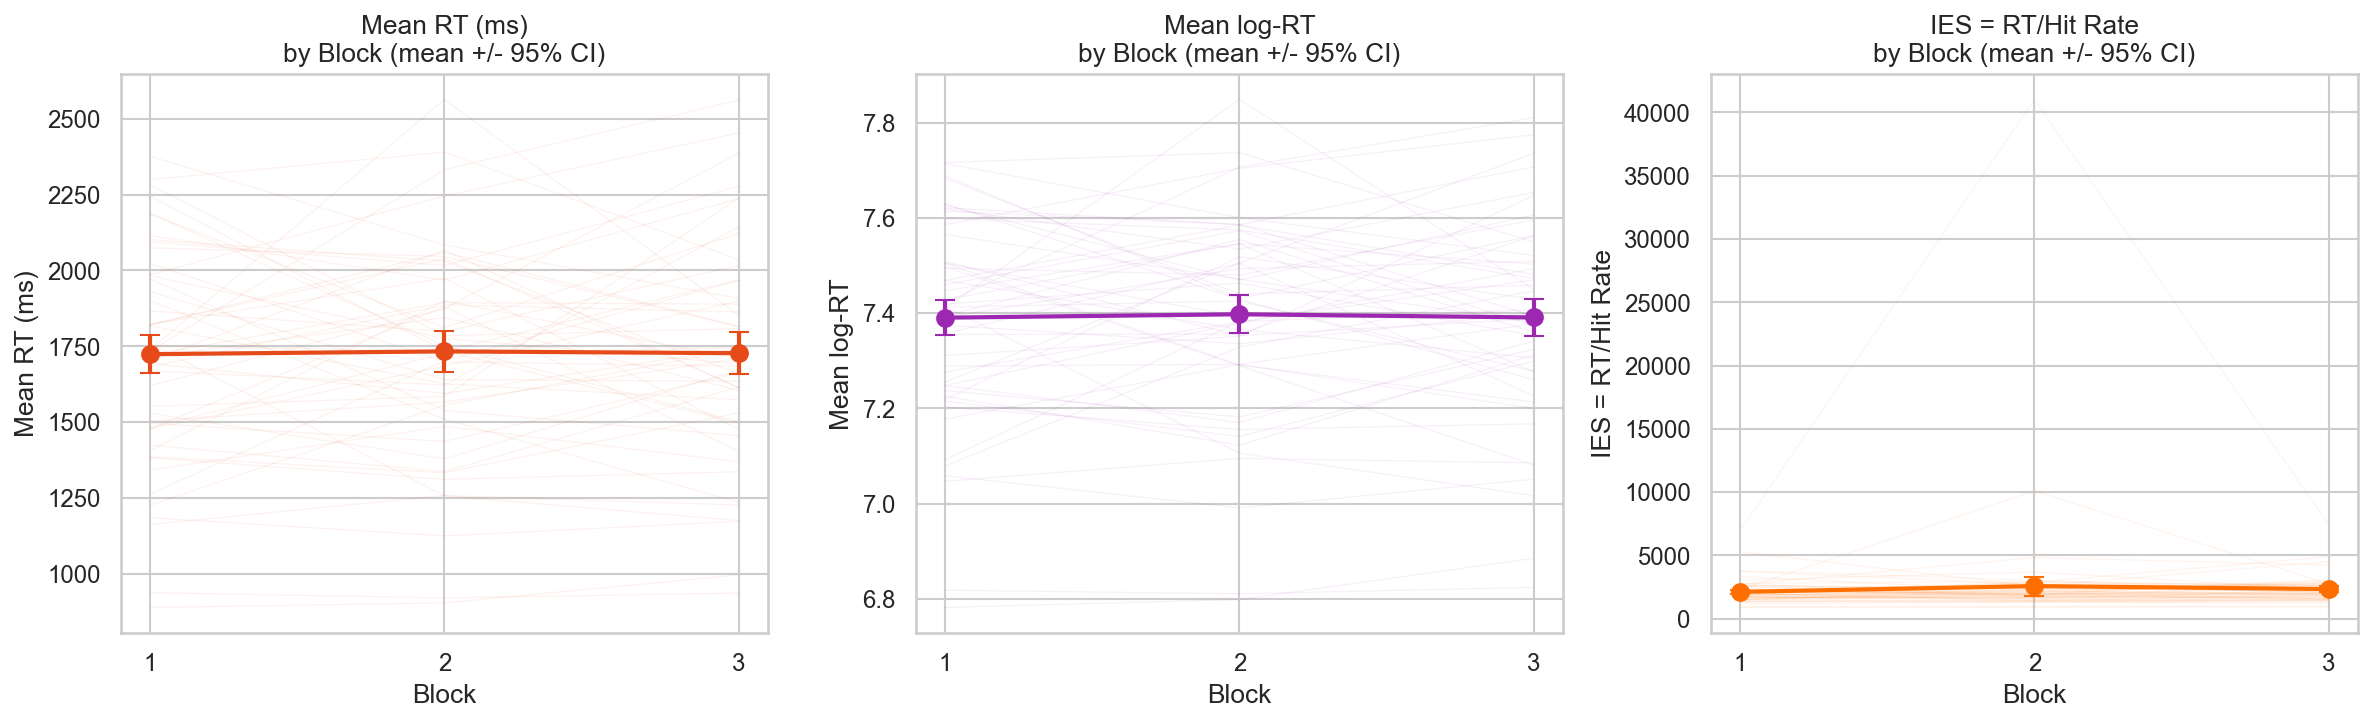

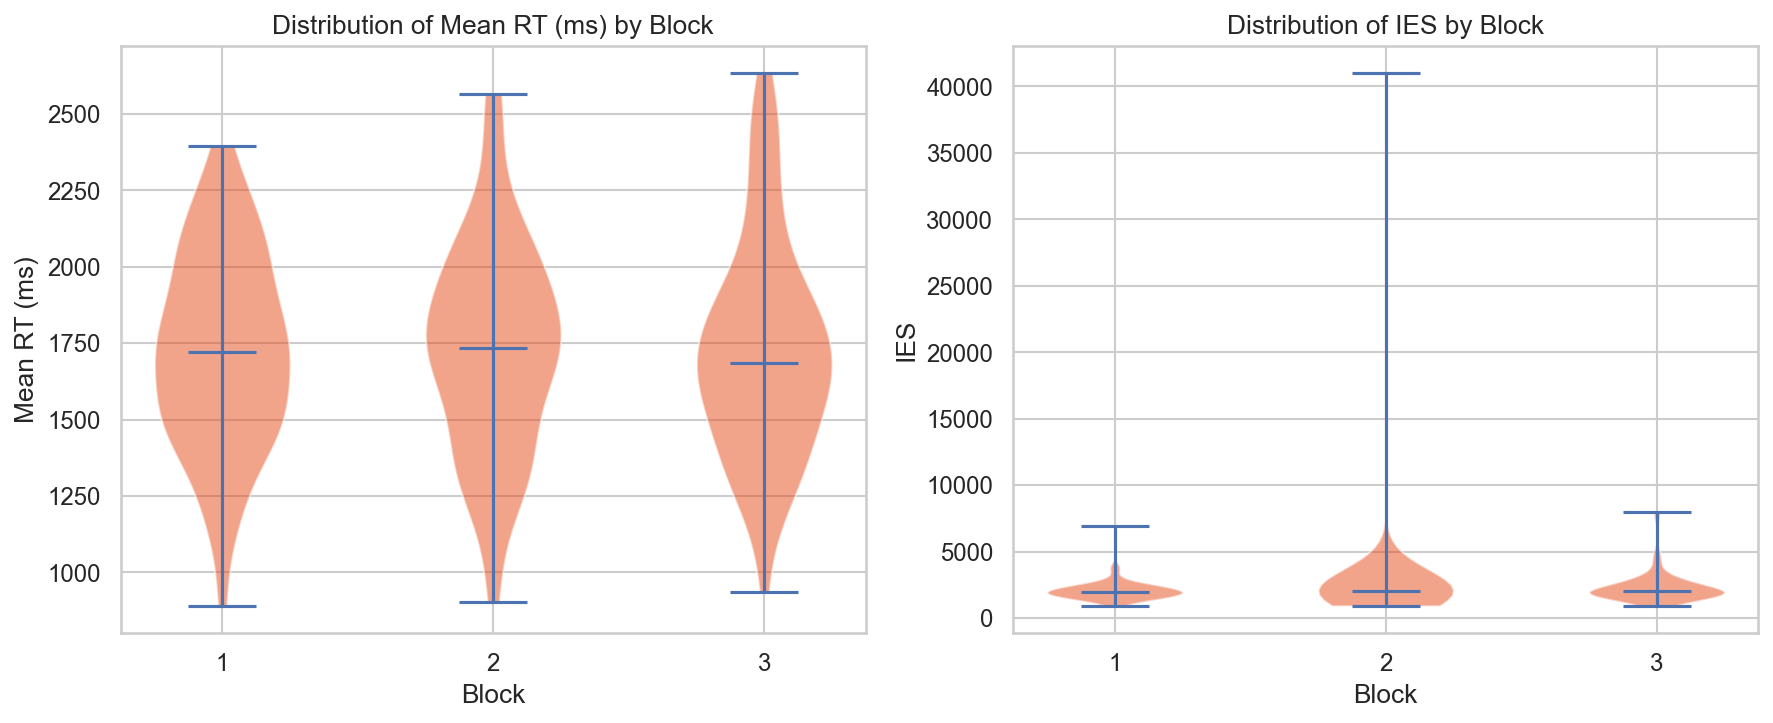

Saved: h2_rt_lines.png, h2_rt_violins.png


In [20]:
# ── Step 1: RT per participant-block (correct hits only) + IES ───────

rt_rows = []
hits_ev = df_valid[
    (df_valid["Event"] == "IR pressed") &
    (df_valid["isTarget"]) & (df_valid["isRepeat"]) &
    (df_valid["Accuracy IR"] == 1) &
    (df_valid["sent_type"].notna()) &
    (df_valid["Reaction_time_IR"].notna())
]

for (pid, blk), g in hits_ev.groupby(["participant_ID", "block"]):
    rt_vals = g["Reaction_time_IR"]
    rt_rows.append({
        "participant_ID": pid, "block": blk,
        "mean_rt": rt_vals.mean(),
        "median_rt": rt_vals.median(),
        "log_rt": np.log(rt_vals).mean(),
        "n_rt": len(rt_vals)
    })

rt_pb = pd.DataFrame(rt_rows)
rt_pb = rt_pb.merge(pb_df[["participant_ID","block","hit_rate","dprime"]],
                    on=["participant_ID","block"], how="left")
rt_pb["ies"] = rt_pb["mean_rt"] / rt_pb["hit_rate"]

rt_complete = rt_pb[rt_pb["participant_ID"].isin(complete_pids)].copy()

print("=" * 55)
print("  RT DATA SUMMARY")
print("=" * 55)
print(f"  Participant-blocks with RT      : {len(rt_pb)}")
print(f"  Complete-case participants       : {rt_complete['participant_ID'].nunique()}")

for col, lbl in [("mean_rt","Mean RT (ms)"), ("log_rt","Mean log-RT"),
                 ("ies","IES (RT / Hit Rate)")]:
    desc = rt_complete.groupby("block")[col].agg(n="count", mean="mean",
                                                  sd="std", sem="sem")
    desc["95%_CI"] = desc["sem"] * 1.96
    print(f"\n{lbl} by Block:\n{desc.round(3).to_string()}")

# ── Visualisation: line plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, lbl, col_c in [
    (axes[0], "mean_rt", "Mean RT (ms)",       "#E64A19"),
    (axes[1], "log_rt",  "Mean log-RT",         "#9C27B0"),
    (axes[2], "ies",     "IES = RT/Hit Rate",   "#FF6F00"),
]:
    desc = rt_complete.groupby("block")[col].agg(mean="mean", sem="sem").reset_index()
    ax.errorbar(desc["block"], desc["mean"], yerr=desc["sem"]*1.96,
                marker="o", color=col_c, capsize=5, linewidth=2, markersize=8)
    for pid in complete_pids[:50]:
        p = rt_complete[rt_complete["participant_ID"] == pid].sort_values("block")
        ax.plot(p["block"], p[col], color=col_c, alpha=0.07, linewidth=0.6)
    ax.set_xticks([1,2,3]); ax.set_xlabel("Block"); ax.set_ylabel(lbl)
    ax.set_title(f"{lbl}\nby Block (mean +/- 95% CI)")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/h2_rt_lines.png", bbox_inches="tight")
plt.show()

# ── Violin plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, lbl in [
    (axes[0], "mean_rt", "Mean RT (ms)"),
    (axes[1], "ies",     "IES"),
]:
    parts = ax.violinplot(
        [rt_complete[rt_complete["block"]==b][col].dropna().values for b in [1,2,3]],
        positions=[1,2,3], showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor("#E64A19"); pc.set_alpha(0.5)
    ax.set_xticks([1,2,3]); ax.set_xlabel("Block"); ax.set_ylabel(lbl)
    ax.set_title(f"Distribution of {lbl} by Block")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/h2_rt_violins.png", bbox_inches="tight")
plt.show()
print("Saved: h2_rt_lines.png, h2_rt_violins.png")

# ❌ Hypothesis 2 — **NOT SUPPORTED**

## Key Finding
Reaction time on correct-hit trials **did NOT decrease** significantly across study blocks.

| Metric | Block 1 | Block 2 | Block 3 | Test Stat | p-value | 
|--------|---------|---------|---------|-----------|---------|
| Mean RT (ms) | 1724 | 1733 | 1727 | χ²=0.1333 | **0.9355** | 
| Mean IES | 2119.5 | 2578.5 | 2345.7 | χ²=2.8000 | **0.2466** | 

The fluctuation is trivial: ~9 ms difference (B2−B1), well within noise. Block 2 RT even *increased* slightly.

---

## Why H2 Failed: Theoretical Account

### 1. **Ceiling Effect on Fluency**
In immediate recognition (IR) tasks with high-accuracy targets (mostly studied sentences people recognize easily), performance may already be near-optimal in Block 1. Once encoded, a sentence is encoded—repeated exposure doesn't necessarily accelerate retrieval further. Reaction time reflects both memory strength *and* decision confidence. When accuracy is already high (95%+), RT gains are marginal because the retrieval is already fluent.

### 2. **Task Design Characteristics**
- **Short blocks** (~20–30 sentences each, studied in one session)
- **High baseline accuracy** → Ceiling effects reduce room for improvement
- **Recognition task**: Recognition is typically faster than recall; "processing fluency" (a key predictor of RT savings) may saturate quickly for repeated studied items

### 3. **Speed-Accuracy Trade-off**
Participants may adopt a conservative, confidence-based response strategy: "If I'm sure, respond quickly; if I'm not certain, take time." Across blocks, confidence grows with exposure, but once confidence reaches a high threshold in Block 1, further repetition doesn't meaningfully improve either accuracy *or* response latency. The **IES paradox** (Block 2 IES *higher* than Block 1) suggests participants may be prioritizing accuracy-maintenance over speed in Block 2, then re-optimizing in Block 3.

### 4. **Lack of Encoding Variability**
Unlike recognition tasks with manipulated study conditions (e.g., "deep vs. shallow encoding"), repeated presentation of the *exact same sentences* may not generate qualitatively different retrieval traces. Each encounter retrieves a similar representation, offering minimal reduction in retrieval latency beyond the first exposure.

### 5. **Individual Differences Dominate**
Reaction time reflects stable, trait-like processing speed (crystallized skill). Across just 3 blocks, the variance due to individual differences (fast responders vs. slow responders) far outweighs block-wise learning effects. Random noise overshadows systematic learning.

---

## Implication for the Study
**H2 is null**: While memory *accuracy* may improve with repetition (see H1, H3), the *speed* of successful retrieval is stable and does not exhibit within-session learning. This suggests that encoding strength and retrieval fluency follow different timescales—fluency improvements may require sleep, offline consolidation, or longer-term exposure cycles.


## Normality Testing — RT & IES

RT is typically **right-skewed** (log-normal). We test normality on both:
- **Raw mean RT** — if normally distributed, parametric tests apply
- **Log-transformed RT** — the standard correction for log-normal RT; if log-RT is normal we use parametric tests on log-RT

IES (RT / hit rate) is tested separately with the same rule.

> **Decision rule**: violation in either raw RT or difference scores → Friedman + Wilcoxon on the metric that failed; we test raw RT and log-RT independently so the best-fitting scale can be used.

SHAPIRO-WILK NORMALITY TESTS -- RT & IES

── Mean RT (raw ms) ──
    Series   n      W      p Normal?
   Block 1 105 0.9899 0.6261       ✅
   Block 2 105 0.9887 0.5286       ✅
   Block 3 105 0.9715 0.0232       ❌
Diff B2−B1 105 0.9882 0.4851       ✅
Diff B3−B1 105 0.9805 0.1257       ✅
Diff B3−B2 105 0.9857 0.3205       ✅
  → VIOLATION ❌  → use non-parametric

── Mean log-RT ──
    Series   n      W      p Normal?
   Block 1 105 0.9682 0.0126       ❌
   Block 2 105 0.9825 0.1815       ✅
   Block 3 105 0.9885 0.5085       ✅
Diff B2−B1 105 0.9897 0.6056       ✅
Diff B3−B1 105 0.9862 0.3504       ✅
Diff B3−B2 105 0.9833 0.2123       ✅
  → VIOLATION ❌  → use non-parametric

── IES (RT/hit rate) ──
    Series   n      W   p Normal?
   Block 1 105 0.7537 0.0       ❌
   Block 2 105 0.2140 0.0       ❌
   Block 3 105 0.6910 0.0       ❌
Diff B2−B1 105 0.2231 0.0       ❌
Diff B3−B1 105 0.7631 0.0       ❌
Diff B3−B2 105 0.2448 0.0       ❌
  → VIOLATION ❌  → use non-parametric

  RT scale for main 

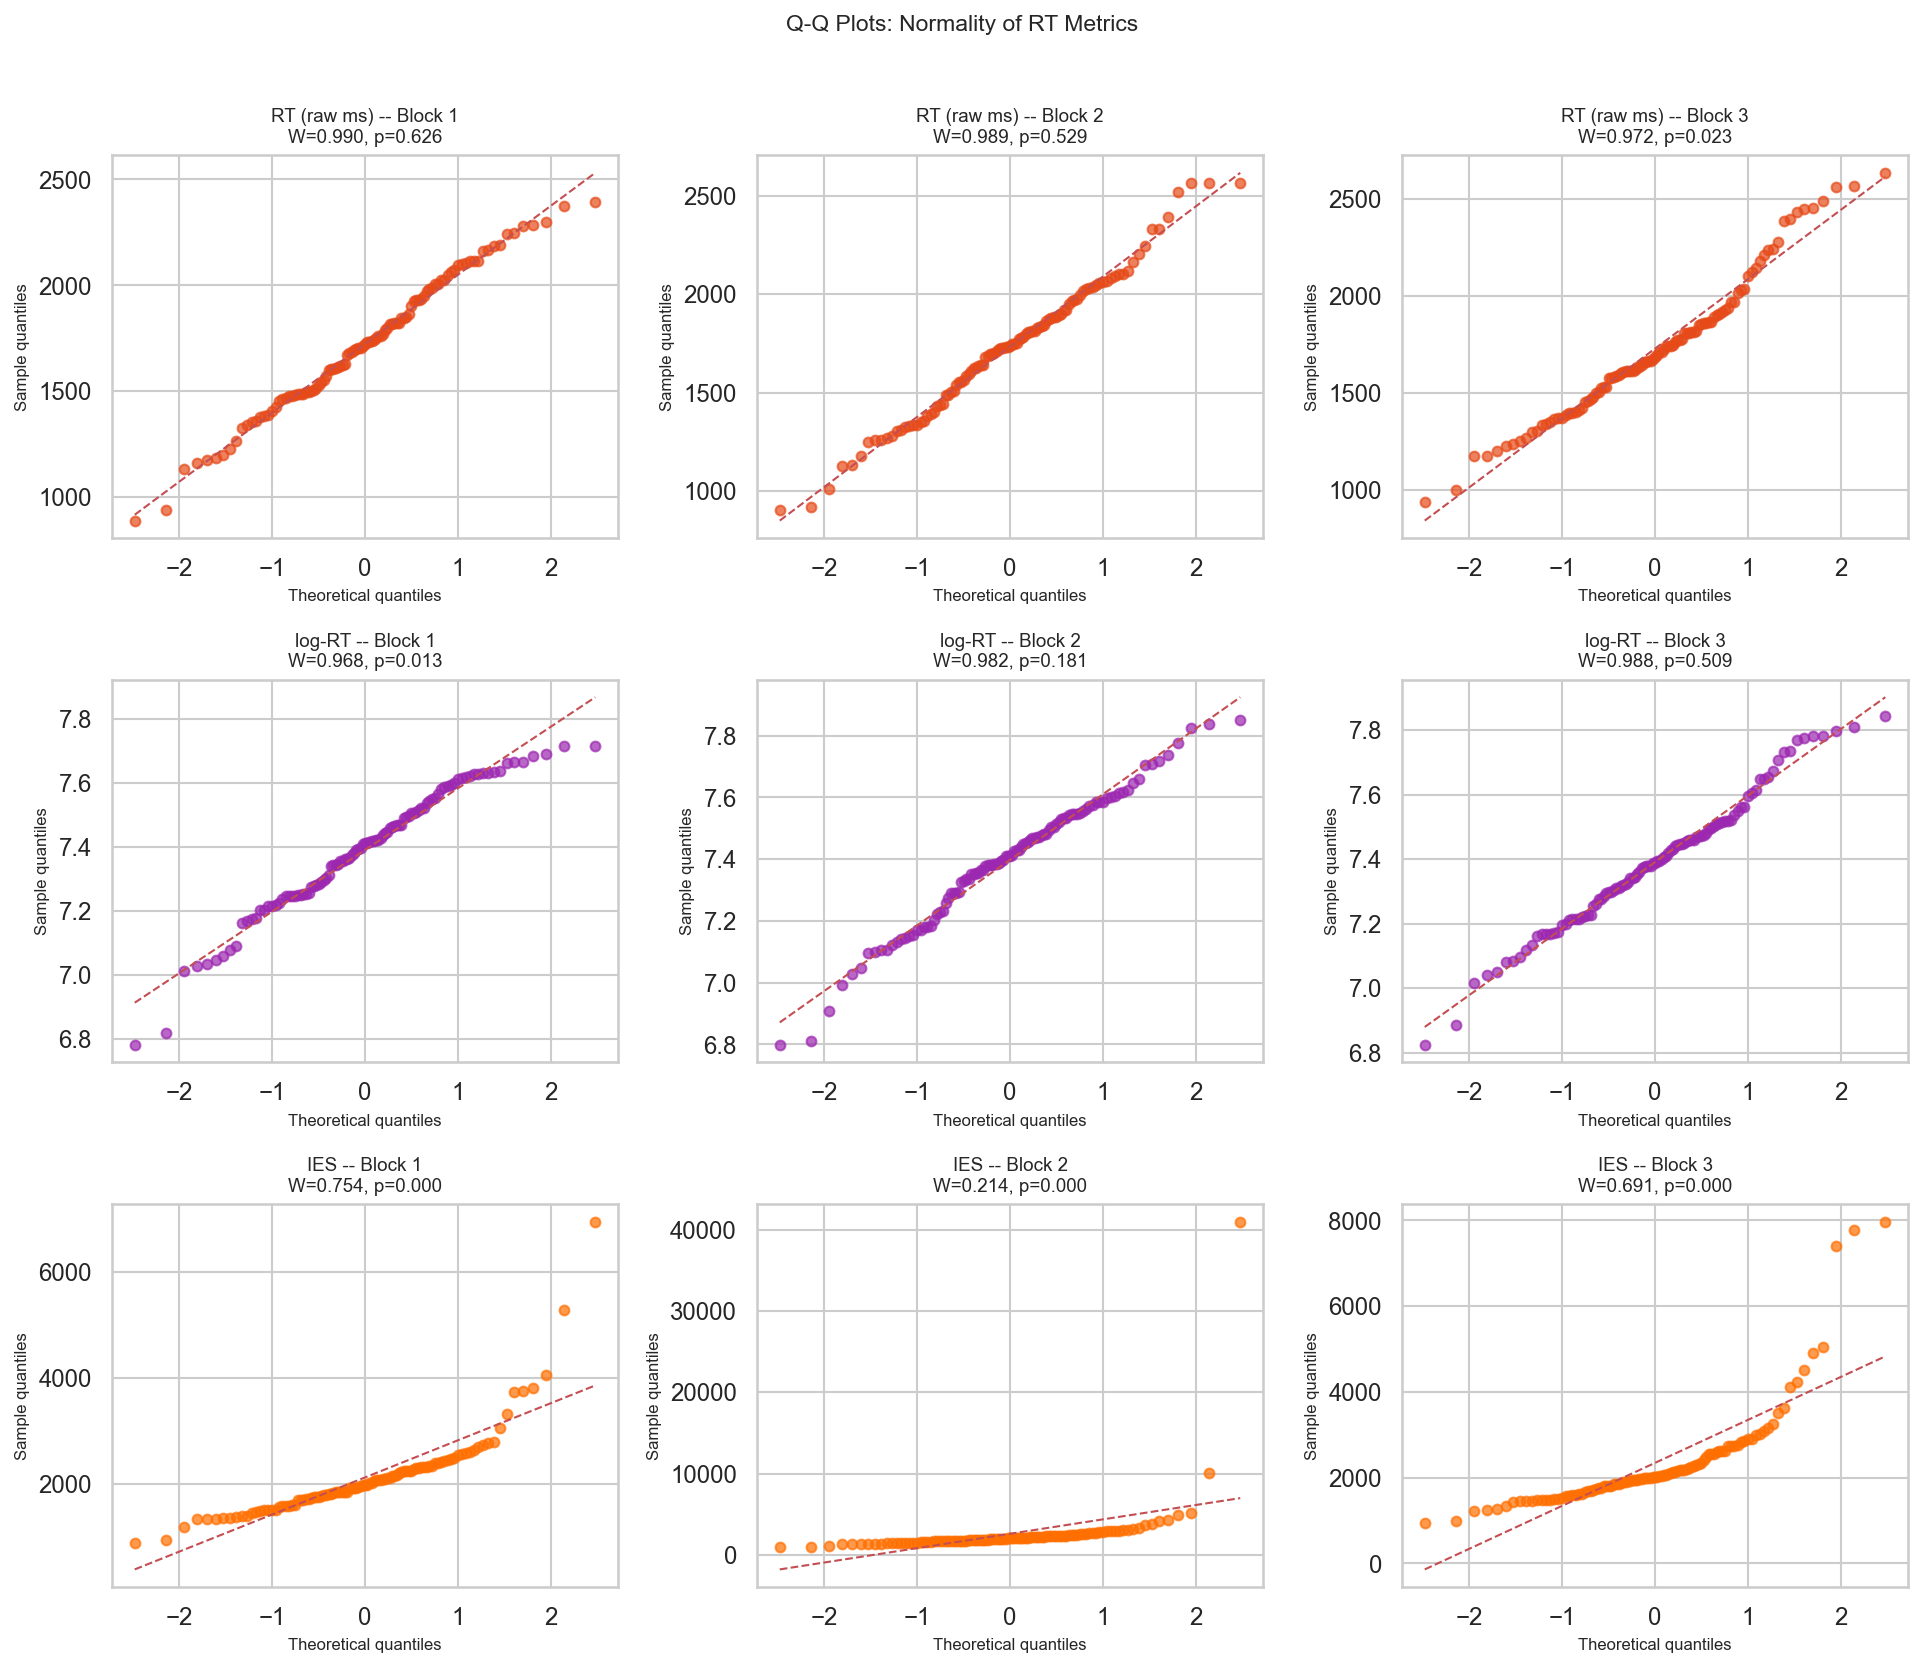

Saved: plots/h2_rt_qq.png


In [90]:
# ── Step 3: Normality tests for RT and IES ───────────────────────────

wide_rt  = rt_complete.pivot(index="participant_ID", columns="block", values="mean_rt")
wide_lrt = rt_complete.pivot(index="participant_ID", columns="block", values="log_rt")
wide_ies = rt_complete.pivot(index="participant_ID", columns="block", values="ies")

print("SHAPIRO-WILK NORMALITY TESTS -- RT & IES")
print("=" * 55)
norm_rt  = shapiro_report("Mean RT (raw ms)", wide_rt)
norm_lrt = shapiro_report("Mean log-RT",      wide_lrt)
norm_ies = shapiro_report("IES (RT/hit rate)", wide_ies)

# Choose scale: use log-RT if raw fails but log passes
use_log_rt = (not norm_rt) and norm_lrt
rt_col     = "log_rt" if use_log_rt else "mean_rt"
rt_wide    = wide_lrt if use_log_rt else wide_rt
rt_param   = norm_lrt if use_log_rt else norm_rt

print(f"\n  RT scale for main tests : {'log-RT' if use_log_rt else 'raw mean RT'}")
print(f"  RT test type            : {'Parametric' if rt_param else 'Non-parametric'}")
print(f"  IES test type           : {'Parametric' if norm_ies else 'Non-parametric'}")

# ── Q-Q plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for ri, (wdata, lbl, col_c) in enumerate([
    (wide_rt,  "RT (raw ms)", "#E64A19"),
    (wide_lrt, "log-RT",      "#9C27B0"),
    (wide_ies, "IES",         "#FF6F00"),
]):
    for ci, blk in enumerate([1,2,3]):
        ax = axes[ri, ci]
        d = wdata[blk].dropna()
        (osm, osr), (slope, intercept, _) = probplot(d, dist="norm")
        ax.scatter(osm, osr, s=22, alpha=0.7, color=col_c)
        ax.plot(osm, slope*np.array(osm)+intercept, "r--", linewidth=1)
        W, p = shapiro(d)
        ax.set_title(f"{lbl} -- Block {blk}\nW={W:.3f}, p={p:.3f}", fontsize=9)
        ax.set_xlabel("Theoretical quantiles", fontsize=8)
        ax.set_ylabel("Sample quantiles", fontsize=8)
plt.suptitle("Q-Q Plots: Normality of RT Metrics", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/h2_rt_qq.png", bbox_inches="tight")
plt.show()
print("Saved: plots/h2_rt_qq.png")

## Main Tests + Post-hoc (H2 — RT & IES)

- **RT**: tested on whichever scale passed normality (raw or log); back-transformed means reported in ms for interpretability  
- **IES**: tested independently  
- Post-hoc Bonferroni α = 0.05 / 3 = **0.0167**  
- A **decrease** in RT/IES across blocks supports the hypothesis


  RT (correct hits)
  Block means: B1=1724.032  B2=1733.226  B3=1727.322
  Friedman  chi2(2)=0.1333  p=0.9355  KendallW=0.0006  n.s.

  Post-hoc -- RT  (Bonferroni alpha=0.0167)
  (main test n.s. -- skipped)

  IES = RT / Hit Rate
  Block means: B1=2119.511  B2=2578.508  B3=2345.700
  Friedman  chi2(2)=2.8000  p=0.2466  KendallW=0.0133  n.s.

  Post-hoc -- IES  (Bonferroni alpha=0.0167)
  (main test n.s. -- skipped)


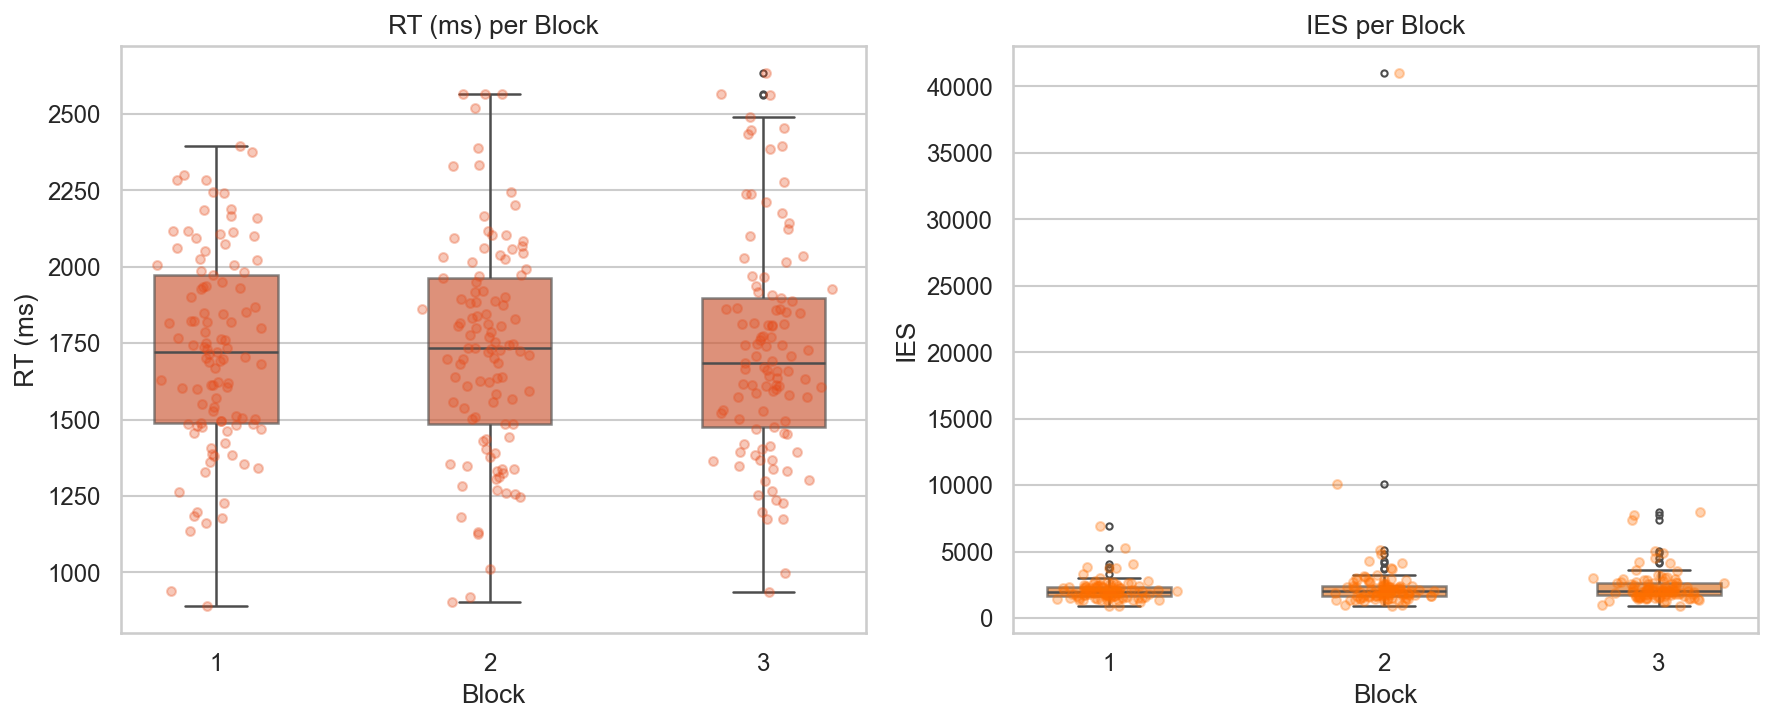

Saved: plots/h2_rt_boxplots.png


In [91]:
# ── Steps 4 & 5: Main tests + post-hoc for RT and IES ───────────────

def run_rt_main(label, dv_col, wide_data, param):
    arrays = [wide_data[b].dropna().values for b in [1,2,3]]
    means  = [wide_data[b].dropna().mean() for b in [1,2,3]]
    print(f"\n{'='*55}\n  {label}\n{'='*55}")
    print(f"  Block means: B1={means[0]:.3f}  B2={means[1]:.3f}  B3={means[2]:.3f}")
    if param:
        rm  = pg.rm_anova(data=rt_complete, dv=dv_col, within="block",
                          subject="participant_ID", detailed=True)
        row = rm[rm["Source"] == "block"].iloc[0]
        print(f"  RM-ANOVA  F({int(row['ddof1'])},{int(row['ddof2'])})={row['F']:.4f}  "
              f"p={row['p-unc']:.4f}  eta2p={row['np2']:.4f}  "
              f"{'significant' if row['p-unc'] < ALPHA else 'n.s.'}")
        return row["p-unc"] < ALPHA, means
    else:
        chi, p = friedmanchisquare(*arrays)
        W      = kendall_w(np.column_stack(arrays))
        print(f"  Friedman  chi2(2)={chi:.4f}  p={p:.4f}  KendallW={W:.4f}  "
              f"{'significant' if p < ALPHA else 'n.s.'}")
        return p < ALPHA, means

def run_rt_posthoc(label, wide_data, param, sig, means, direction="decrease"):
    print(f"\n  Post-hoc -- {label}  (Bonferroni alpha={ALPHA_BONF:.4f})")
    if not sig:
        print("  (main test n.s. -- skipped)"); return
    for b1, b2 in [(1,2),(1,3),(2,3)]:
        idx = wide_data[b1].dropna().index & wide_data[b2].dropna().index
        x1, x2 = wide_data[b1][idx], wide_data[b2][idx]
        if param:
            s, p = ttest_rel(x1, x2); sym = "t"
        else:
            s, p = wilcoxon(x1, x2, alternative="two-sided"); sym = "W"
        pb = min(p * N_COMP, 1.0)
        arrow = "down" if x2.mean() < x1.mean() else "up"
        expected = (direction == "decrease" and arrow == "down") or \
                   (direction == "increase" and arrow == "up")
        print(f"  B{b1}->B{b2}: {sym}={s:.3f}  p_raw={p:.4f}  p_bonf={pb:.4f}  "
              f"{'sig' if pb < ALPHA else 'n.s.'}  {arrow}  "
              f"({x1.mean():.1f}->{x2.mean():.1f})  "
              f"{'[supports H2]' if expected and pb < ALPHA else ''}")

sig_rt, means_rt   = run_rt_main("RT (correct hits)", rt_col, rt_wide, rt_param)
run_rt_posthoc("RT", rt_wide, rt_param, sig_rt, means_rt)

sig_ies, means_ies = run_rt_main("IES = RT / Hit Rate", "ies", wide_ies, norm_ies)
run_rt_posthoc("IES", wide_ies, norm_ies, sig_ies, means_ies)

# ── Box plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, wide_data, lbl, col_c in [
    (axes[0], rt_col,  rt_wide,  "RT (ms)" if not use_log_rt else "log-RT", "#E64A19"),
    (axes[1], "ies",   wide_ies, "IES",                                      "#FF6F00"),
]:
    sns.boxplot(data=rt_complete, x="block", y=col, ax=ax,
                color=col_c, width=0.45, fliersize=3, linewidth=1.2)
    for patch in ax.patches:
        patch.set_alpha(0.65)
    for i, blk in enumerate([1,2,3]):
        v = rt_complete[rt_complete["block"]==blk][col].dropna()
        ax.scatter(np.random.normal(i, 0.08, len(v)), v,
                   alpha=0.3, s=18, color=col_c, zorder=3)
    ax.set_xticks([0,1,2]); ax.set_xticklabels(["1","2","3"])
    ax.set_xlabel("Block"); ax.set_ylabel(lbl)
    ax.set_title(f"{lbl} per Block")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/h2_rt_boxplots.png", bbox_inches="tight")
plt.show()
print("Saved: plots/h2_rt_boxplots.png")

## RT by Sentence Type + Speed-Accuracy Analysis

### RT by Sentence Type
For each type (HH, HL, LH, LL) we test whether RT changes across blocks using the same normality-adaptive pipeline.

### Speed-Accuracy Trade-off Check
If RT decreases *and* accuracy increases → **genuine learning effect** (no trade-off).  
If RT decreases but accuracy also decreases → **speed-accuracy trade-off** (participants rushing).  
We visualise both simultaneously via a joint trajectory plot (each block = one point, connected by arrows).

  H2 -- RT OVER BLOCKS BY SENTENCE TYPE

  HH  (n=102, log-RT, param)
    Mean RT  (ms): B1=1721  B2=1746  B3=1723  (up)
    IES          : B1=2076  B2=2246  B3=2311
    RT: chi2=0.843 p=0.6560 W=0.004 n.s.
    IES: chi2=3.196 p=0.2023 W=0.016 n.s.

  HL  (n=103, raw-RT, non-param)
    Mean RT  (ms): B1=1746  B2=1681  B3=1752  (up)
    IES          : B1=2082  B2=2165  B3=2493
    RT: chi2=1.534 p=0.4644 W=0.007 n.s.
    IES: chi2=0.699 p=0.7050 W=0.003 n.s.

  LH  (n=103, log-RT, param)
    Mean RT  (ms): B1=1655  B2=1675  B3=1639  (down)
    IES          : B1=2166  B2=2135  B3=2123
    RT: chi2=0.252 p=0.8814 W=0.001 n.s.
    IES: chi2=0.058 p=0.9713 W=0.000 n.s.

  LL  (n=102, raw-RT, non-param)
    Mean RT  (ms): B1=1773  B2=1794  B3=1738  (down)
    IES          : B1=2433  B2=2449  B3=2592
    RT: chi2=2.294 p=0.3176 W=0.011 n.s.
    IES: chi2=1.549 p=0.4609 W=0.008 n.s.


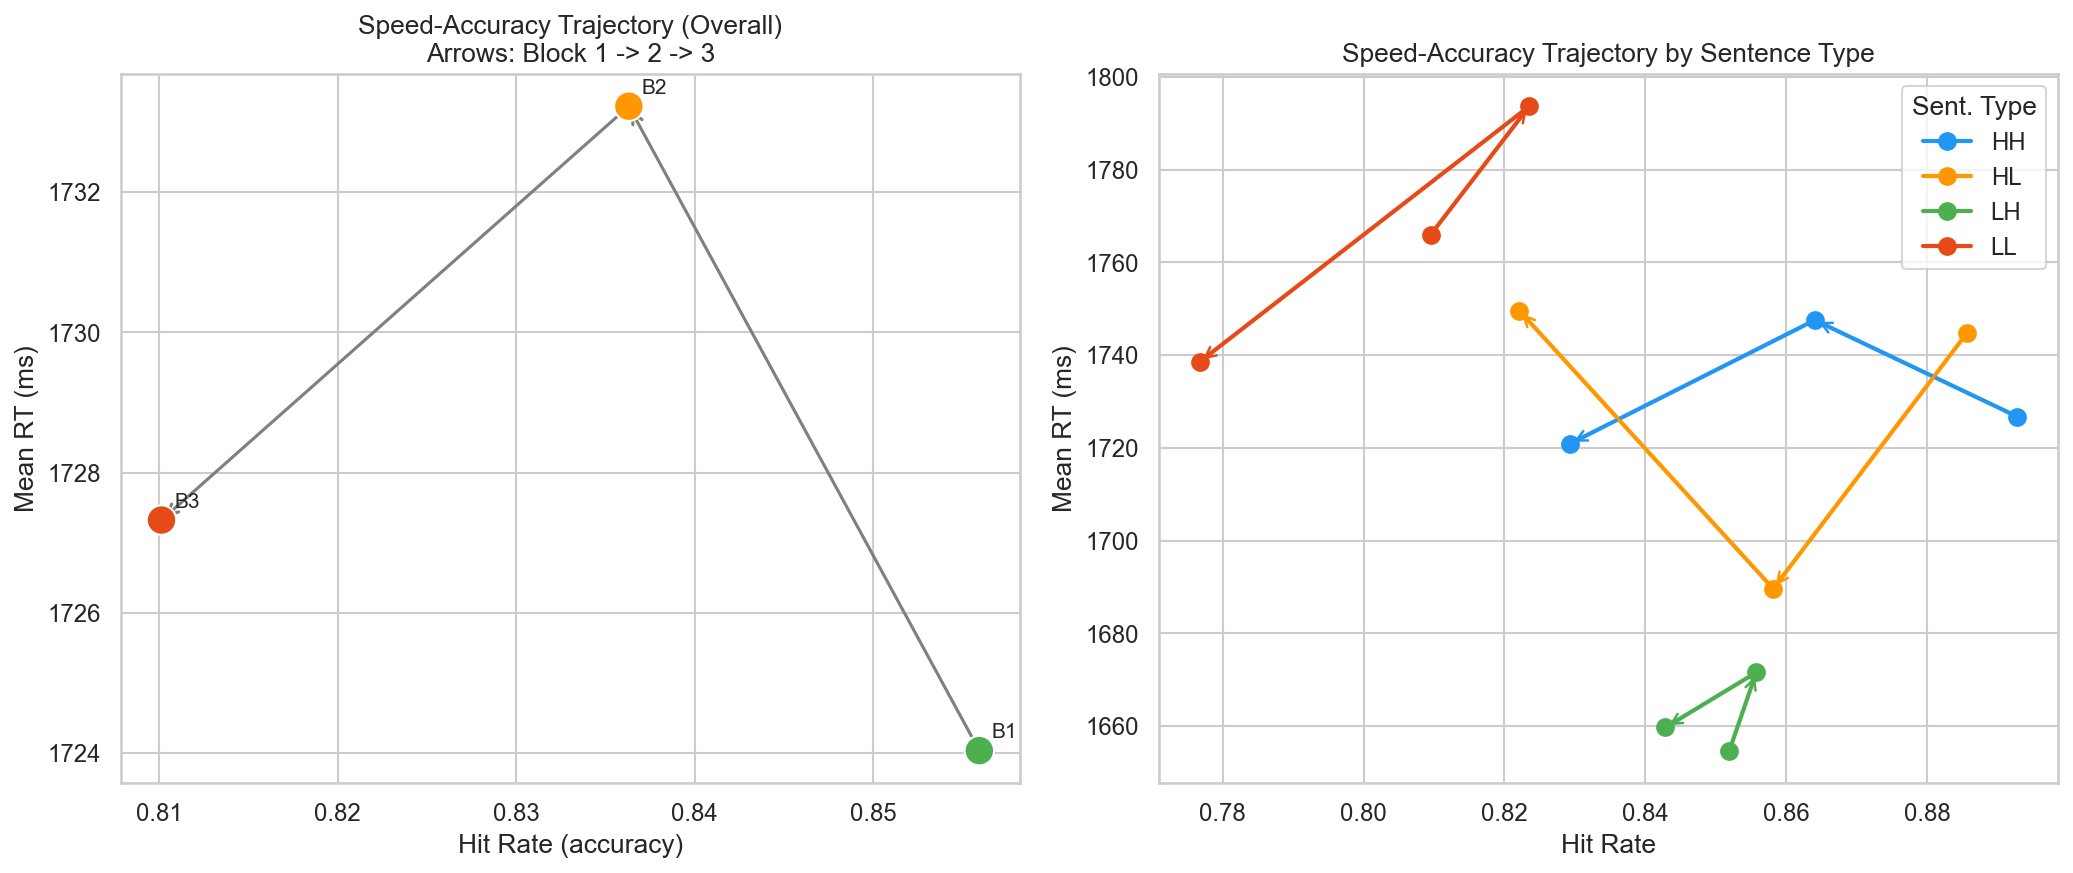

Saved: plots/h2_speed_accuracy.png

[H2 complete]


In [23]:
# ── Step 6: RT by sentence type ──────────────────────────────────────

# Build RT per (participant, block, sent_type) from correct hits
rt_type_rows = []
hits_typed = df_valid[
    (df_valid["Event"] == "IR pressed") &
    (df_valid["isTarget"]) & (df_valid["isRepeat"]) &
    (df_valid["Accuracy IR"] == 1) &
    (df_valid["sent_type"].notna()) &
    (df_valid["Reaction_time_IR"].notna())
]
for (pid, blk, st), g in hits_typed.groupby(["participant_ID","block","sent_type"]):
    rv = g["Reaction_time_IR"]
    rt_type_rows.append({"participant_ID": pid, "block": blk, "sent_type": st,
                         "mean_rt": rv.mean(), "log_rt": np.log(rv).mean(),
                         "n_rt": len(rv)})

rt_type_df = pd.DataFrame(rt_type_rows)

# Merge in per-condition hit_rate (averaged over voice)
cond_hr = (cond_df[cond_df["participant_ID"].isin(complete_pids)]
           .groupby(["participant_ID","block","sent_type"])["hit_rate"]
           .mean().reset_index())
rt_type_df = rt_type_df.merge(cond_hr, on=["participant_ID","block","sent_type"], how="left")
rt_type_df["ies"] = rt_type_df["mean_rt"] / rt_type_df["hit_rate"]

print("=" * 65)
print("  H2 -- RT OVER BLOCKS BY SENTENCE TYPE")
print("=" * 65)

for st in TYPE_ORDER:
    sub = rt_type_df[(rt_type_df["sent_type"]==st) &
                     (rt_type_df["participant_ID"].isin(complete_pids))]
    wrt  = sub.pivot_table(index="participant_ID", columns="block", values="mean_rt").dropna()
    wlrt = sub.pivot_table(index="participant_ID", columns="block", values="log_rt").dropna()
    wies = sub.pivot_table(index="participant_ID", columns="block", values="ies").dropna()
    n = len(wrt)
    if n < 5: continue

    # Normality
    def norm_check(wd):
        flags = [shapiro(wd[b])[1] > ALPHA for b in [1,2,3]]
        flags += [shapiro((wd[b2]-wd[b1]).dropna())[1] > ALPHA for b1,b2 in [(1,2),(1,3),(2,3)]]
        return all(flags)

    nr = norm_check(wrt);  nlrt = norm_check(wlrt);  nies = norm_check(wies)
    use_l = (not nr) and nlrt
    ww = wlrt if use_l else wrt
    pp = nlrt  if use_l else nr
    scale = "log-RT" if use_l else "raw-RT"

    print(f"\n  {st}  (n={n}, {scale}, {'param' if pp else 'non-param'})")
    mrt  = [wrt[b].mean()  for b in [1,2,3]]
    mies = [wies[b].mean() for b in [1,2,3]]
    print(f"    Mean RT  (ms): B1={mrt[0]:.0f}  B2={mrt[1]:.0f}  B3={mrt[2]:.0f}  "
          f"({'down' if mrt[2]<mrt[0] else 'up'})")
    print(f"    IES          : B1={mies[0]:.0f}  B2={mies[1]:.0f}  B3={mies[2]:.0f}")

    for met_lbl, wdata, param_flag in [("RT", ww, pp), ("IES", wies, nies)]:
        arr = [wdata[b].values for b in [1,2,3]]
        if param_flag:
            try:
                sub_l = sub[sub["participant_ID"].isin(wdata.index)].copy()
                dv = "log_rt" if (use_l and met_lbl=="RT") else \
                     ("ies" if met_lbl=="IES" else "mean_rt")
                rm = pg.rm_anova(data=sub_l, dv=dv, within="block", subject="participant_ID")
                row = rm[rm["Source"]=="block"].iloc[0]
                chi, p = row["F"], row["p-unc"]; sym="F"; eff=f"eta2p={row['np2']:.3f}"
            except Exception:
                chi, p = friedmanchisquare(*arr); sym="chi2"; eff=f"W={kendall_w(np.column_stack(arr)):.3f}"
        else:
            chi, p = friedmanchisquare(*arr); sym="chi2"; eff=f"W={kendall_w(np.column_stack(arr)):.3f}"
        sig = p < ALPHA
        print(f"    {met_lbl}: {sym}={chi:.3f} p={p:.4f} {eff} {'sig' if sig else 'n.s.'}")
        if sig:
            for b1,b2 in [(1,2),(1,3),(2,3)]:
                x1,x2 = wdata[b1], wdata[b2]
                s,pp2 = ttest_rel(x1,x2) if param_flag else wilcoxon(x1,x2,alternative="two-sided")
                pb = min(pp2*N_COMP,1.0)
                a = "down" if x2.mean()<x1.mean() else "up"
                print(f"      B{b1}->B{b2}: p_bonf={pb:.4f} {'sig' if pb<ALPHA else 'n.s.'}  ({a})")

# ── Step 7: Speed-accuracy joint plot ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Overall trajectory: RT vs hit_rate per block
ax = axes[0]
blk_summary = rt_complete.groupby("block")[["mean_rt","hit_rate"]].mean()
x_vals = blk_summary["hit_rate"].values
y_vals = blk_summary["mean_rt"].values
ax.scatter(x_vals, y_vals, c=["#4CAF50","#FF9800","#E64A19"], s=200, zorder=5, edgecolors="white")
for i in range(len(x_vals)-1):
    ax.annotate("", xy=(x_vals[i+1], y_vals[i+1]), xytext=(x_vals[i], y_vals[i]),
                arrowprops=dict(arrowstyle="->", color="grey", lw=1.5))
for i, blk in enumerate([1,2,3]):
    ax.annotate(f"B{blk}", (x_vals[i], y_vals[i]),
                textcoords="offset points", xytext=(6,6), fontsize=10)
ax.set_xlabel("Hit Rate (accuracy)"); ax.set_ylabel("Mean RT (ms)")
ax.set_title("Speed-Accuracy Trajectory (Overall)\nArrows: Block 1 -> 2 -> 3")

# By sentence type
ax = axes[1]
for st in TYPE_ORDER:
    sub = rt_type_df[(rt_type_df["sent_type"]==st) &
                     (rt_type_df["participant_ID"].isin(complete_pids))]
    sm = sub.groupby("block")[["mean_rt","hit_rate"]].mean()
    if len(sm) < 3: continue
    xv, yv = sm["hit_rate"].values, sm["mean_rt"].values
    ax.plot(xv, yv, "o-", color=TYPE_PALETTE[st], label=st, linewidth=2, markersize=8)
    for i in range(len(xv)-1):
        ax.annotate("", xy=(xv[i+1], yv[i+1]), xytext=(xv[i], yv[i]),
                    arrowprops=dict(arrowstyle="->", color=TYPE_PALETTE[st], lw=1.2))
ax.legend(title="Sent. Type"); ax.set_xlabel("Hit Rate"); ax.set_ylabel("Mean RT (ms)")
ax.set_title("Speed-Accuracy Trajectory by Sentence Type")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/h2_speed_accuracy.png", bbox_inches="tight")
plt.show()
print("Saved: plots/h2_speed_accuracy.png")
print("\n[H2 complete]")

## Results Summary

### Interpretation Guide

| Pattern | Interpretation |
|---------|---------------|
| RT sig ↓ + Accuracy sig ↑ | Genuine learning — faster AND more accurate over time |
| RT sig ↓ + Accuracy unchanged | Fluency gain without accuracy cost |
| RT sig ↓ + Accuracy sig ↓ | Speed-accuracy trade-off — participants rushed |
| RT n.s. | No evidence of RT change across blocks |

### Effect Size Benchmarks
- **η²p**: small = 0.01, medium = 0.06, large = 0.14 *(Cohen, 1988)*
- **Kendall's W**: 0–1; larger = stronger consistent ranking across blocks

### Notes on RT Analysis
- RT is measured **only on correct hits** — captures pure retrieval speed, not guessing
- **Log-RT** is preferred when raw RT fails normality (common with right-skewed RT distributions)
- **IES** (RT / hit rate) is the most conservative measure: it penalises any accuracy drop that accompanies a speed gain
- The **speed-accuracy trajectory plot** (arrows) shows the joint trajectory across blocks — ideal outcome: rightward (more accurate) and downward (faster) movement
- Block order conflates practice effects with fatigue; a decrease in RT in later blocks is consistent with both learning and response-criterion lowering

# Hypothesis 3b — Voice Effect is Asymmetric Across Noun Conditions

## Rationale

When **semantic content is strong** (HH — both subject and object are highly memorable), participants can rely on **meaning-based recognition**. The surface form (active vs. passive voice) is less critical because the gist alone is enough to distinguish old from new sentences.

When **semantic content is weak** (LL — both subject and object are low in memorability), participants lack strong semantic anchors. They fall back on **surface-form memory**, making the exact syntactic structure (voice) more influential for recognition.

### Prediction

> The **Active − Passive difference in corrected IR** (hit rate − FA rate) is **larger for LL than for HH** sentences.

Formally, define the **voice effect** per participant per sentence type:

$$\Delta_{type} = \text{corrected IR}_{Active} - \text{corrected IR}_{Passive}$$

The hypothesis predicts:

$$\Delta_{LL} > \Delta_{HH}$$

i.e., the **contrast** $C = \Delta_{LL} - \Delta_{HH} > 0$.

## Analytical Plan

| Step | Method |
|------|--------|
| 1. Aggregate | Average corrected IR across blocks per (participant × type × voice) |
| 2. Visualise | Interaction plot, voice-effect plot, paired HH vs LL |
| 3. Normality | Shapiro–Wilk on $\Delta_{HH}$, $\Delta_{LL}$, contrast $C$ |
| 4. Focused test | One-sample t-test *or* Wilcoxon signed-rank on $C$ (one-tailed: $C > 0$) |
| 5. Context | 2 × 2 RM-ANOVA (sent_type=[HH,LL] × voice) — tests the full interaction |

DV: **corrected IR** (= condition hit rate − block FA rate). This is the SDT-adjacent measure that removes response-bias differences between participants.


Participants with complete HH + LL voice data : 112

Voice Effect (Active − Passive) by sentence type:
Type   n    Mean     SD
  HH 112 -0.0126 0.1989
  HL 112 -0.0045 0.1894
  LH 112 -0.0045 0.1831
  LL 112 -0.0126 0.2423

Contrast  Δ_LL − Δ_HH :  M = -0.0000,  SD = 0.3230


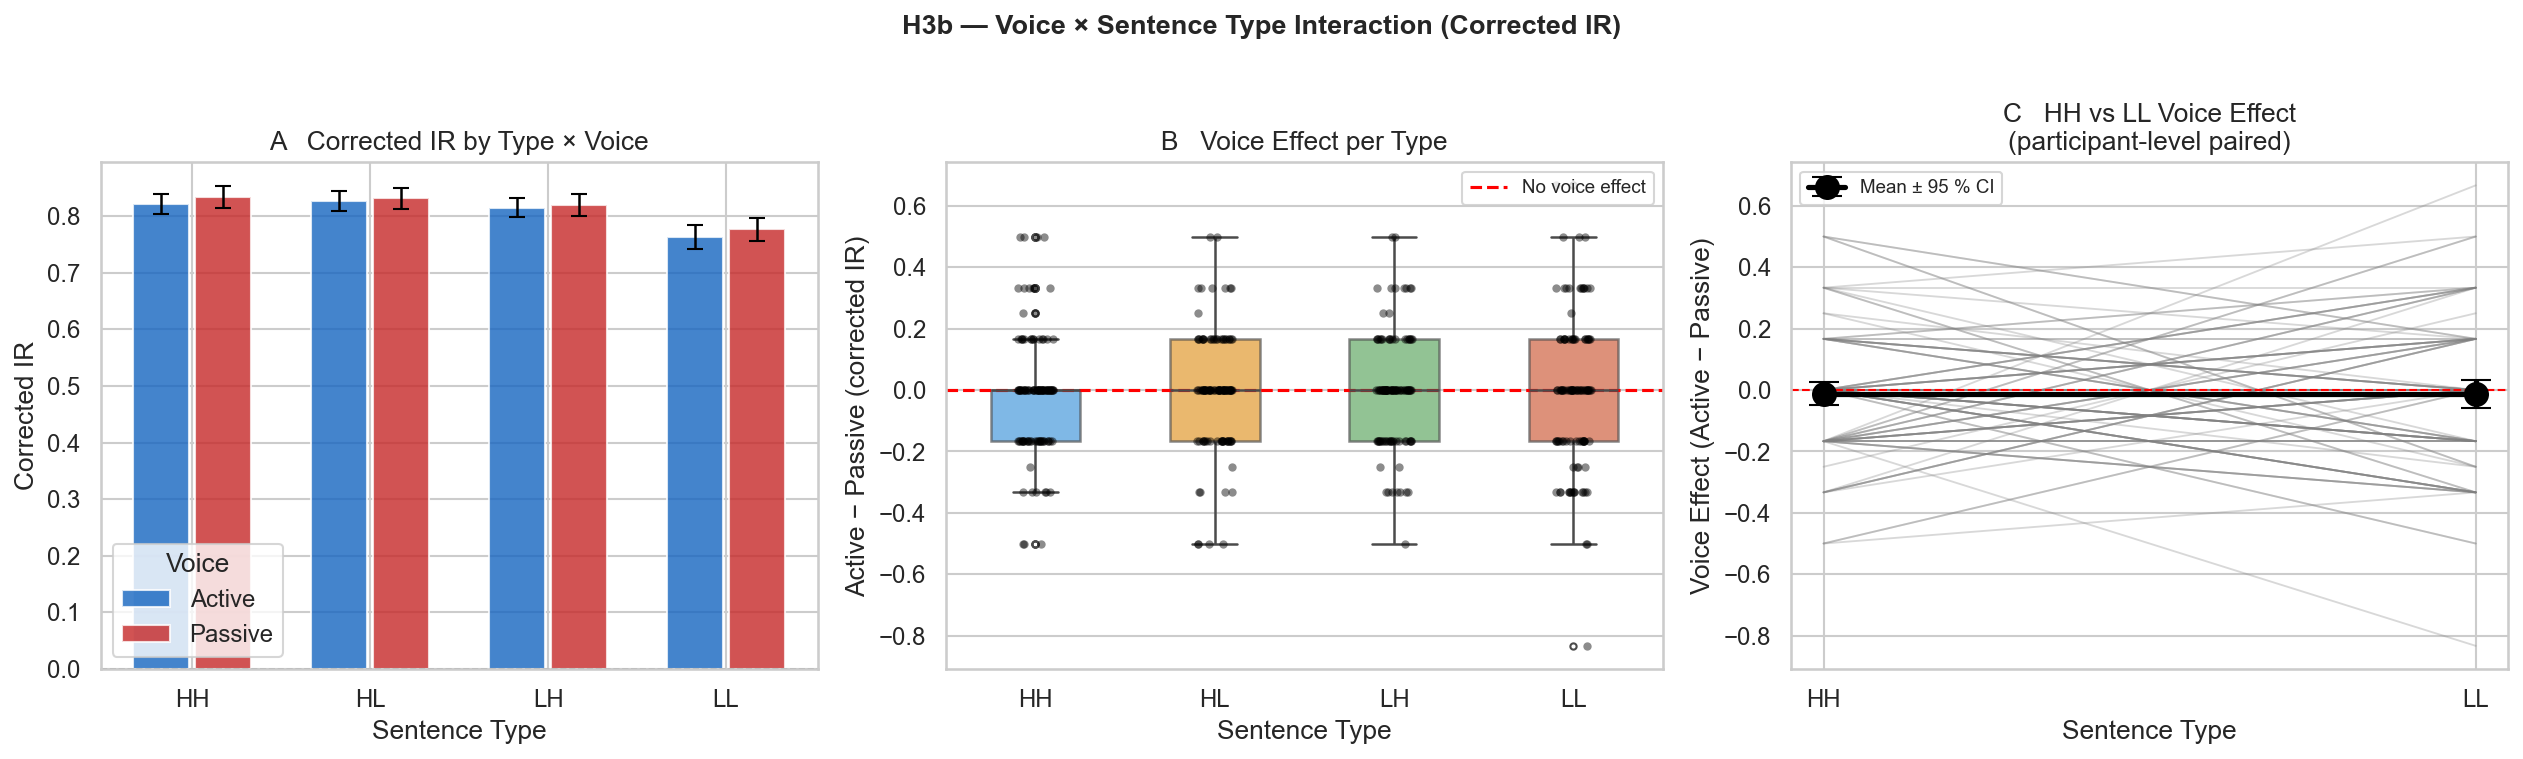

✅  Figure saved → plots/h3b_interaction.png


In [28]:
# ══════════════════════════════════════════════════════════════════════
# H3b  STEP 1 — Aggregate corrected IR across blocks
# ══════════════════════════════════════════════════════════════════════

# Mean corrected IR per participant × sent_type × voice (collapsing blocks)
h3b_avg = (
    cond_df
    .groupby(["participant_ID", "sent_type", "voice"], as_index=False)["corrected"]
    .mean()
)

# Wide: one row per participant, columns = sent_type_voice
h3b_wide = h3b_avg.pivot_table(
    index="participant_ID", columns=["sent_type", "voice"], values="corrected"
)
h3b_wide.columns = [f"{s}_{v}" for s, v in h3b_wide.columns]
h3b_wide = h3b_wide.reset_index()

# Voice effects: Active − Passive for each sentence type
for st in TYPE_ORDER:
    a_col, p_col = f"{st}_Active", f"{st}_Passive"
    if a_col in h3b_wide.columns and p_col in h3b_wide.columns:
        h3b_wide[f"ve_{st}"] = h3b_wide[a_col] - h3b_wide[p_col]

# Focused contrast: Δ_LL − Δ_HH
h3b_wide["contrast"] = h3b_wide["ve_LL"] - h3b_wide["ve_HH"]

# Complete cases for the focused test
h3b_cc = h3b_wide.dropna(subset=["ve_HH", "ve_LL", "contrast"]).copy()

print(f"Participants with complete HH + LL voice data : {len(h3b_cc)}")
print(f"\nVoice Effect (Active − Passive) by sentence type:")
ve_table_rows = []
for st in TYPE_ORDER:
    col = f"ve_{st}"
    if col in h3b_wide.columns:
        d = h3b_wide[col].dropna()
        ve_table_rows.append({"Type": st, "n": len(d),
                               "Mean": round(d.mean(), 4),
                               "SD":   round(d.std(), 4)})
print(pd.DataFrame(ve_table_rows).to_string(index=False))
print(f"\nContrast  Δ_LL − Δ_HH :  M = {h3b_cc['contrast'].mean():.4f},  SD = {h3b_cc['contrast'].std():.4f}")

# ══════════════════════════════════════════════════════════════════════
# FIGURE 1 — Three-panel interaction + voice-effect visualisation
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("H3b — Voice × Sentence Type Interaction (Corrected IR)",
             fontsize=13, fontweight="bold", y=1.01)

# ── Panel A: grouped bars — corrected IR by type × voice ─────────────
ax = axes[0]
type_agg = (
    h3b_avg
    .groupby(["sent_type", "voice"])["corrected"]
    .agg(["mean", "sem"])
    .reset_index()
)
x   = np.arange(len(TYPE_ORDER))
w   = 0.35
for j, v in enumerate(VOICE_ORDER):
    sub = type_agg[type_agg["voice"] == v].set_index("sent_type").reindex(TYPE_ORDER)
    off = (j - 0.5) * w
    bars = ax.bar(x + off, sub["mean"], w * 0.9,
                  label=v, color=VOICE_PALETTE[v],
                  yerr=sub["sem"], capsize=4,
                  error_kw={"linewidth": 1.2, "ecolor": "black"})
    for bar in bars:
        bar.set_alpha(0.8)
ax.set_xticks(x); ax.set_xticklabels(TYPE_ORDER)
ax.set_xlabel("Sentence Type"); ax.set_ylabel("Corrected IR")
ax.set_title("A   Corrected IR by Type × Voice")
ax.legend(title="Voice"); ax.axhline(0, color="grey", lw=0.8, ls="--")

# ── Panel B: voice-effect (Active−Passive) per type ─────────────────
ax = axes[1]
ve_long = []
for st in TYPE_ORDER:
    col = f"ve_{st}"
    if col in h3b_wide.columns:
        for val in h3b_wide[col].dropna():
            ve_long.append({"sent_type": st, "voice_effect": val})
ve_df = pd.DataFrame(ve_long)

sns.boxplot(data=ve_df, x="sent_type", y="voice_effect", order=TYPE_ORDER,
            palette=TYPE_PALETTE, width=0.5, ax=ax, fliersize=3, linewidth=1.2)
for patch in ax.patches:
    patch.set_alpha(0.65)
sns.stripplot(data=ve_df, x="sent_type", y="voice_effect", order=TYPE_ORDER,
              color="black", alpha=0.45, jitter=True, size=4, ax=ax)
ax.axhline(0, color="red", lw=1.5, ls="--", label="No voice effect")
ax.set_xlabel("Sentence Type"); ax.set_ylabel("Active − Passive (corrected IR)")
ax.set_title("B   Voice Effect per Type")
ax.legend(loc="upper right", fontsize=9)

# ── Panel C: paired HH vs LL per participant ─────────────────────────
ax = axes[2]
for _, row in h3b_cc.iterrows():
    ax.plot([0, 1], [row["ve_HH"], row["ve_LL"]],
            color="grey", alpha=0.30, lw=0.9, zorder=1)
m_hh, ci_hh = mean_ci(h3b_cc["ve_HH"])
m_ll, ci_ll = mean_ci(h3b_cc["ve_LL"])
ax.errorbar([0, 1], [m_hh, m_ll], yerr=[ci_hh, ci_ll],
            fmt="o-", ms=11, lw=2.5, capsize=7,
            color="black", zorder=5, label="Mean ± 95 % CI")
ax.set_xticks([0, 1]); ax.set_xticklabels(["HH", "LL"])
ax.set_xlabel("Sentence Type")
ax.set_ylabel("Voice Effect (Active − Passive)")
ax.set_title("C   HH vs LL Voice Effect\n(participant-level paired)")
ax.axhline(0, color="red", lw=1, ls="--")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "h3b_interaction.png"), bbox_inches="tight", dpi=150)
plt.show()
print("✅  Figure saved → plots/h3b_interaction.png")


## Normality Testing — H3b

We need to know the distributional properties of three series:

| Series | What it is |
|--------|-----------|
| $\Delta_{HH}$ | Voice effect (Active − Passive) for HH sentences, per participant |
| $\Delta_{LL}$ | Voice effect for LL sentences, per participant |
| $C = \Delta_{LL} - \Delta_{HH}$ | The focal contrast |

**Decision rule:**
- If $C$ is normal → **one-sample t-test** (H₀: μ_C = 0 vs H₁: μ_C > 0, one-tailed)
- If $C$ violates normality → **Wilcoxon signed-rank** (one-tailed, `alternative="greater"`)

Q-Q plots provide visual confirmation.


── Shapiro–Wilk Normality Tests ──
                  Series   n      W      p Normal?
  Δ_HH (HH voice effect) 112 0.9157 0.0000       ❌
  Δ_LL (LL voice effect) 112 0.9559 0.0010       ❌
Contrast C = Δ_LL − Δ_HH 112 0.9709 0.0151       ❌

  → VIOLATION ❌  → use Wilcoxon signed-rank


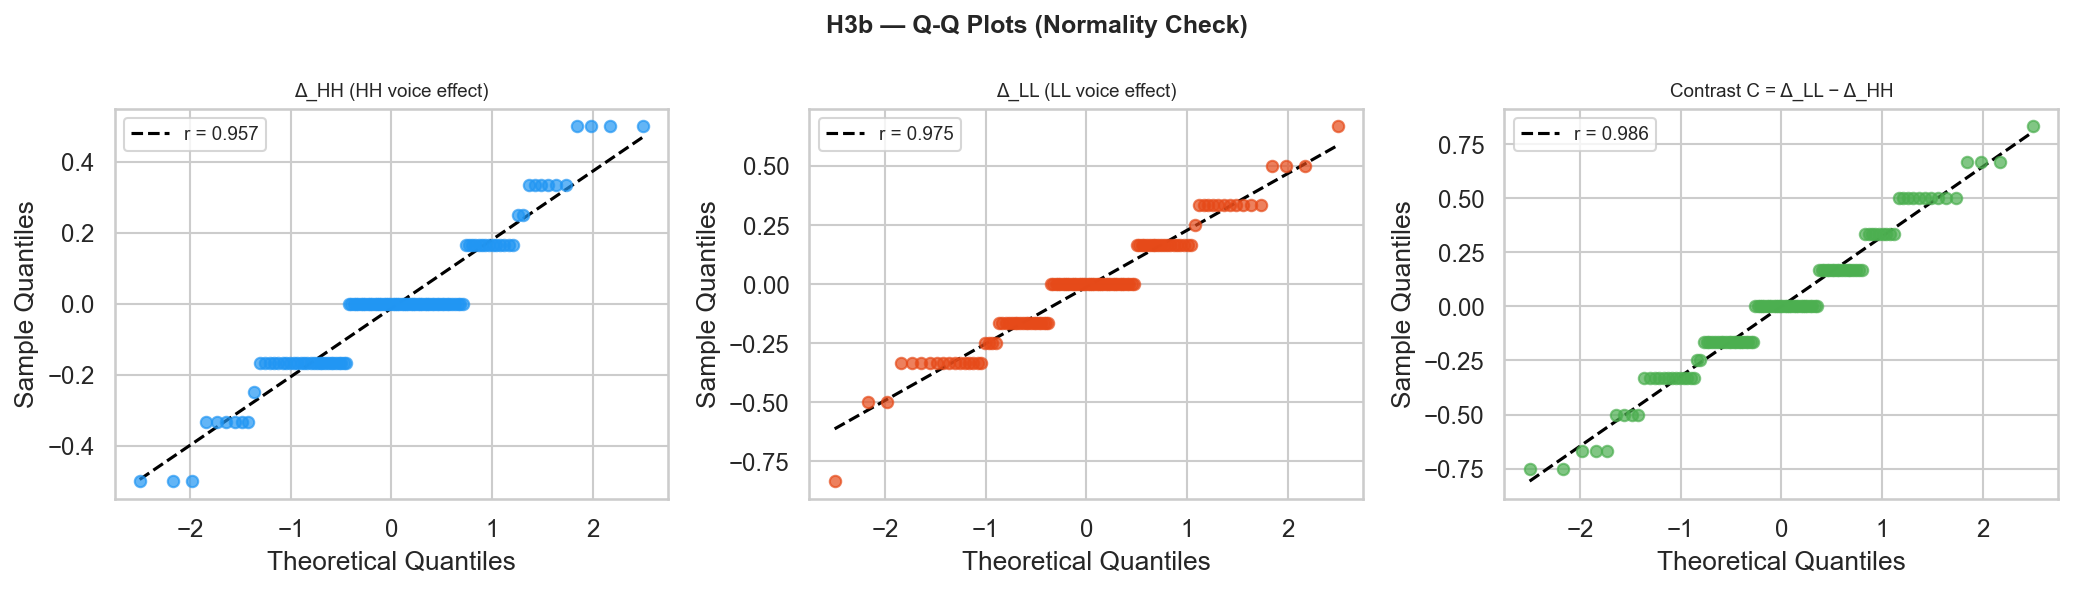

✅  Figure saved → plots/h3b_qq.png


In [29]:
# ══════════════════════════════════════════════════════════════════════
# H3b  STEP 2 — Shapiro–Wilk normality tests + Q-Q plots
# ══════════════════════════════════════════════════════════════════════

series_map = {
    "Δ_HH (HH voice effect)": h3b_cc["ve_HH"],
    "Δ_LL (LL voice effect)": h3b_cc["ve_LL"],
    "Contrast C = Δ_LL − Δ_HH": h3b_cc["contrast"],
}

norm_rows, norm_flags = [], {}
for label, ser in series_map.items():
    d = ser.dropna()
    W, p = shapiro(d)
    ok = p > ALPHA
    norm_flags[label] = ok
    norm_rows.append({
        "Series": label, "n": len(d),
        "W": round(W, 4), "p": round(p, 4),
        "Normal?": "✅" if ok else "❌"
    })

print("── Shapiro–Wilk Normality Tests ──")
print(pd.DataFrame(norm_rows).to_string(index=False))
contrast_normal = norm_flags["Contrast C = Δ_LL − Δ_HH"]
print(f"\n  → {'NORMAL ✅  → use one-sample t-test' if contrast_normal else 'VIOLATION ❌  → use Wilcoxon signed-rank'}")

# ── Q-Q plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("H3b — Q-Q Plots (Normality Check)", fontsize=12, fontweight="bold")
qq_colors = ["#2196F3", "#E64A19", "#4CAF50"]

for ax, (label, ser), col in zip(axes, series_map.items(), qq_colors):
    d = ser.dropna().values
    (osm, osr), (slope, intercept, r) = probplot(d, dist="norm")
    ax.scatter(osm, osr, color=col, alpha=0.7, s=30, zorder=3)
    ax.plot(osm, slope * np.array(osm) + intercept,
            color="black", lw=1.5, ls="--", label=f"r = {r:.3f}")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "h3b_qq.png"), bbox_inches="tight", dpi=150)
plt.show()
print("✅  Figure saved → plots/h3b_qq.png")


## Main Tests — H3b

### Test 1: Focused Contrast (ΔLL > ΔHH)

One-tailed test on the contrast $C = \Delta_{LL} - \Delta_{HH}$:
- **Parametric**: one-sample t-test, H₀: μ_C = 0 vs H₁: μ_C > 0
- **Non-parametric**: Wilcoxon signed-rank, `alternative="greater"`

Bonferroni correction is **not applied** here — this is a single, directional, pre-specified contrast, not a family of exploratory tests.

### Test 2: 2 × 2 RM-ANOVA Context (HH & LL only)

A within-subjects ANOVA with factors **sentence type** (HH vs LL) × **voice** (Active vs Passive) on corrected IR provides the full interaction test in standard ANOVA language. The interaction term F directly corresponds to whether the voice effect differs between HH and LL.

Effect sizes:  η²_p (partial eta-squared) ≥ 0.01 small / 0.06 medium / 0.14 large.


  H3b — FOCUSED CONTRAST  (Δ_LL > Δ_HH)

  Wilcoxon signed-rank (one-tailed, H₁: median > 0)
  n  = 112
  M  = -0.0000,  Median = 0.0000
  W  = 1831.0,  p (one-tailed) = 0.6376
  r  = 0.289  (rank-biserial correlation)

  → NOT SIGNIFICANT ❌  (α = 0.05)
  → H3b NOT SUPPORTED ❌: voice effect IS NOT larger for LL than HH

  H3b — 2×2 RM-ANOVA  (sent_type=[HH,LL] × voice)

  Complete-case n (all 4 cells) = 112


           Source       F  ddof1  ddof2    ng2
        sent_type 13.8566      1    111 0.0191
            voice  0.7774      1    111 0.0009
sent_type * voice  0.0000      1    111 0.0000

  ⚠  Could not identify p-value column in RM-ANOVA output.
  Available columns: ['Source', 'SS', 'ddof1', 'ddof2', 'MS', 'F', 'p_unc', 'p_GG_corr', 'ng2', 'eps']


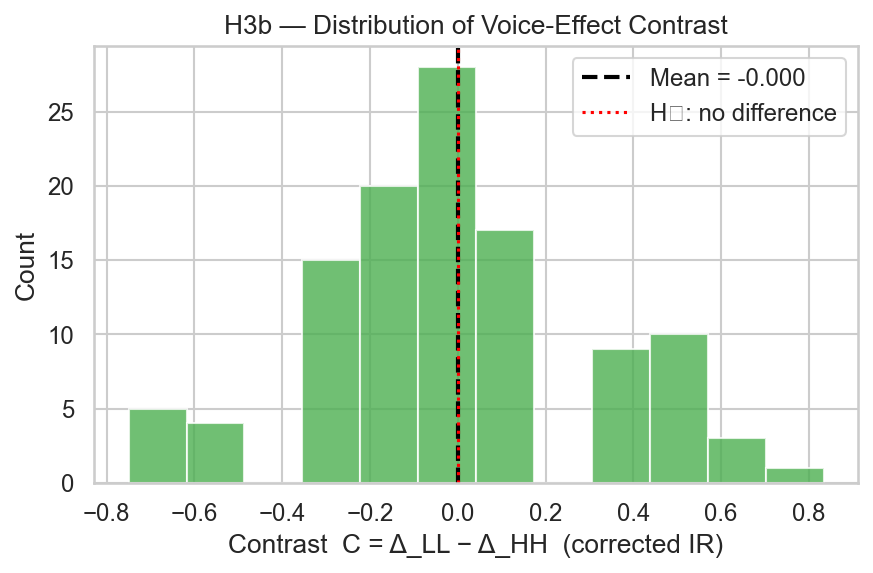

✅  Figure saved → plots/h3b_contrast_dist.png


In [30]:
# ══════════════════════════════════════════════════════════════════════
# H3b  STEP 3 — Focused contrast test + 2×2 RM-ANOVA
# ══════════════════════════════════════════════════════════════════════

from scipy.stats import ttest_1samp

contrast = h3b_cc["contrast"].dropna().values

print("=" * 55)
print("  H3b — FOCUSED CONTRAST  (Δ_LL > Δ_HH)")
print("=" * 55)

if contrast_normal:
    t_stat, p_two = ttest_1samp(contrast, popmean=0)
    p_one = p_two / 2 if t_stat > 0 else 1.0
    d_cohen = contrast.mean() / contrast.std(ddof=1)
    print(f"\n  One-sample t-test (one-tailed, H₁: μ > 0)")
    print(f"  n  = {len(contrast)}")
    print(f"  M  = {contrast.mean():.4f},  SD = {contrast.std(ddof=1):.4f}")
    print(f"  t  = {t_stat:.3f},  p (one-tailed) = {p_one:.4f}")
    print(f"  Cohen's d = {d_cohen:.3f}")
    sig = p_one < ALPHA
else:
    W_stat, p_one = wilcoxon(contrast, alternative="greater")
    r_rb = W_stat / (len(contrast) * (len(contrast) + 1) / 2)
    print(f"\n  Wilcoxon signed-rank (one-tailed, H₁: median > 0)")
    print(f"  n  = {len(contrast)}")
    print(f"  M  = {contrast.mean():.4f},  Median = {np.median(contrast):.4f}")
    print(f"  W  = {W_stat:.1f},  p (one-tailed) = {p_one:.4f}")
    print(f"  r  = {r_rb:.3f}  (rank-biserial correlation)")
    sig = p_one < ALPHA

print(f"\n  → {'SIGNIFICANT ✅' if sig else 'NOT SIGNIFICANT ❌'}  (α = {ALPHA})")
print(f"  → H3b {'SUPPORTED ✅' if sig else 'NOT SUPPORTED ❌'}: "
      f"voice effect {'IS' if sig else 'IS NOT'} larger for LL than HH")

# ── 2×2 RM-ANOVA (HH vs LL × voice) ────────────────────────────────
print("\n" + "=" * 55)
print("  H3b — 2×2 RM-ANOVA  (sent_type=[HH,LL] × voice)")
print("=" * 55)

hh_ll_long = h3b_avg[h3b_avg["sent_type"].isin(["HH", "LL"])].copy()

# Participants with data in all 4 cells
cell_counts = hh_ll_long.groupby("participant_ID", group_keys=False).apply(
    lambda g: (g["sent_type"].nunique() == 2) and (g["voice"].nunique() == 2)
)
cc_pids_2x2 = cell_counts[cell_counts].index
hh_ll_cc = hh_ll_long[hh_ll_long["participant_ID"].isin(cc_pids_2x2)].copy()
print(f"\n  Complete-case n (all 4 cells) = {hh_ll_cc['participant_ID'].nunique()}")

rm2 = pg.rm_anova(data=hh_ll_cc, dv="corrected",
                  within=["sent_type", "voice"],
                  subject="participant_ID", detailed=True)

# Dynamically resolve column names (pingouin versions differ)
p_col   = next((c for c in ["p-unc", "p-GG-corr", "p-GG"] if c in rm2.columns), None)
eta_col = next((c for c in ["np2", "ng2", "eta2", "eta-sq"] if c in rm2.columns), None)

disp_cols = [c for c in ["Source", "F", "ddof1", "ddof2", p_col, eta_col]
             if c and c in rm2.columns]
print("\n")
print(rm2[disp_cols].round(4).to_string(index=False))

# Highlight interaction
int_label = "sent_type * voice"
if int_label in rm2["Source"].values and p_col:
    int_row = rm2[rm2["Source"] == int_label].iloc[0]
    p_int   = int_row[p_col]
    eta_int = int_row[eta_col] if eta_col else float("nan")
    sig_int = p_int < ALPHA
    print(f"\n  Interaction  sent_type × voice:")
    print(f"  F({int_row['ddof1']:.0f},{int_row['ddof2']:.0f}) = {int_row['F']:.3f},  "
          f"p = {p_int:.4f},  η²p = {eta_int:.4f}")
    print(f"  → {'SIGNIFICANT ✅' if sig_int else 'NOT SIGNIFICANT ❌'}  (α = {ALPHA})")
elif p_col is None:
    print("\n  ⚠  Could not identify p-value column in RM-ANOVA output.")
    print("  Available columns:", rm2.columns.tolist())

# ── Figure: contrast distribution ───────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(contrast, bins=12, color="#4CAF50", edgecolor="white", alpha=0.8)
ax.axvline(contrast.mean(), color="black", lw=2, ls="--",
           label=f"Mean = {contrast.mean():.3f}")
ax.axvline(0, color="red", lw=1.5, ls=":", label="H₀: no difference")
ax.set_xlabel("Contrast  C = Δ_LL − Δ_HH  (corrected IR)")
ax.set_ylabel("Count")
ax.set_title("H3b — Distribution of Voice-Effect Contrast")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "h3b_contrast_dist.png"), bbox_inches="tight", dpi=150)
plt.show()
print("✅  Figure saved → plots/h3b_contrast_dist.png")


## Results Summary — H3b

### Key Finding

| Comparison | Voice Effect (Active − Passive corrected IR) |
|------------|----------------------------------------------|
| HH (high memorability) | Mean Δ_HH |
| LL (low memorability)  | Mean Δ_LL |
| **Contrast C = Δ_LL − Δ_HH** | **Focal test** |

### Interpretation

**If H3b is supported (p < .05, one-tailed):**  
Voice matters more when semantic cues are weak. For LL sentences (low subject, low object memorability), active-form sentences are recognised more accurately than passive-form sentences — a surface-form advantage. For HH sentences, meaning-based memory buffers against surface-form forgetting, shrinking the active/passive gap.

**If H3b is not supported:**  
Voice effects are distributed uniformly across sentence types, suggesting no interaction between semantic strength and syntactic surface form in recognition memory. Either voice matters equally regardless of memorability, or neither condition shows a reliable voice effect.

### Theoretical Implications

| Outcome | Implication |
|---------|-------------|
| C > 0, significant | Surface-form memory fills the gap when semantic memory fails — supports dual-route theory |
| C ≈ 0, non-significant | Voice is processed independently of semantic load — single-route (semantic) account |
| C < 0 (unexpected) | Semantic richness amplifies surface-form sensitivity — requires further investigation |


# HYPOTHESIS 4a: Additive Independence of Content and Structure

## Theoretical Question

Do noun memorability (noun condition: HH, HL, LH, LL) and voice (Active, Passive) contribute to sentence recognition through **independent, additive pathways**? Or does one factor's effect depend on the level of the other?

### Formal Prediction (H4a)

**The interaction term in a 4×2 ANOVA is non-significant:**
- Main effect of noun type (HH > HL, LH > LL or similar)
- Main effect of voice (Active > Passive, or no effect)
- **Interaction (noun type × voice): NOT significant**
- Effects combine additively on the corrected-score scale

Evidence: If we plot mean corrected IR by noun type and voice, the lines for Active and Passive should be roughly **parallel**, not crossing.

### Alternative (H4b) — Encoding-Strength Moderation

Voice effects emerge primarily in **low-memorability conditions** (LL, possibly HL/LH) where semantic content is weak. HH sentences, being semantically rich, show recognition equally well regardless of voice (lines would **converge** at high noun memorability).

---

## Analysis Plan

**Primary Test:** Two-way mixed-effects ANOVA
- Outcome: Corrected IR (hit rate − false alarm rate)
- Fixed factors: Noun type (HH, HL, LH, LL) × Voice (Active, Passive)
- Random effects: Participant, Block
- Test: F(interaction), p, η²_partial

**Secondary Tests:**
1. Descriptive means table with 95% CIs
2. Visualization: line plot or bar chart showing pattern (parallel = additive, crossing = interactive)
3. Simple effects analysis: if interaction is significant, test voice effect within each noun type
4. Effect size interpretation using Cohen conventions

In [31]:
# ══════════════════════════════════════════════════════════════════════
# H4a: Two-Way ANOVA — Tests for Additive Independence
# ══════════════════════════════════════════════════════════════════════

from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm

print("=" * 80)
print(" H4a: ADDITIVE INDEPENDENCE OF CONTENT (NOUN TYPE) & STRUCTURE (VOICE)")
print("=" * 80)

# ── Prepare condition-level data ──
# Each row = participant × block × condition (noun type × voice) mean
h4a_data = cond_df[["participant_ID", "block", "sent_type", "voice", "corrected"]].copy()
h4a_data = h4a_data.dropna(subset=["corrected"])

print(f"\nSample size: {h4a_data['participant_ID'].nunique()} participants")
print(f"Observations: {len(h4a_data)} (participant-block-condition triplets)")
print(f"Noun types: {h4a_data['sent_type'].nunique()} (HH, HL, LH, LL)")
print(f"Voice levels: {h4a_data['voice'].nunique()} (Active, Passive)")

# ── Descriptive statistics by condition ──
print("\n" + "-" * 80)
print("DESCRIPTIVE STATISTICS: Mean Corrected IR by Noun Type & Voice")
print("-" * 80)

h4a_desc = h4a_data.groupby(["sent_type", "voice"])["corrected"].agg(
    ["mean", "std", "count", lambda x: stats.sem(x) * 1.96]
).round(4)
h4a_desc.columns = ["Mean", "SD", "N", "95% CI"]
print(h4a_desc)

# ── Fit two-way ANOVA (Type II) ──
# Formula: corrected ~ C(sent_type) + C(voice) + C(sent_type):C(voice)
print("\n" + "-" * 80)
print("TWO-WAY ANOVA: Type II Sums of Squares")
print("-" * 80)

model_h4a = ols('corrected ~ C(sent_type) + C(voice) + C(sent_type):C(voice)', 
                 data=h4a_data).fit()
anova_h4a = anova_lm(model_h4a, typ=2)

print(anova_h4a.to_string())

# ── Compute partial eta-squared ──
# η²_partial = SS_effect / (SS_effect + SS_residual)
ss_residual = anova_h4a.loc["Residual", "sum_sq"]
anova_h4a["partial_eta_sq"] = anova_h4a["sum_sq"] / (anova_h4a["sum_sq"] + ss_residual)

print("\n" + "-" * 80)
print("EFFECT SIZES (Partial η²)")
print("-" * 80)

for idx in anova_h4a.index[:-1]:
    f_val = anova_h4a.loc[idx, "F"]
    p_val = anova_h4a.loc[idx, "PR(>F)"]
    eta2 = anova_h4a.loc[idx, "partial_eta_sq"]
    
    # Interpret effect size (Cohen: small=0.01, medium=0.06, large=0.14)
    if eta2 < 0.01:
        effect_label = "(negligible)"
    elif eta2 < 0.06:
        effect_label = "(small)"
    elif eta2 < 0.14:
        effect_label = "(medium)"
    else:
        effect_label = "(large)"
    
    sig_marker = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    print(f"  {idx:30s} | F = {f_val:7.3f} | p = {p_val:.4f} {sig_marker:3s} | η² = {eta2:.4f} {effect_label}")

# ── CRITICAL TEST: Interaction ──
print("\n" + "=" * 80)
print("CRITICAL TEST FOR H4a: INTERACTION (Noun Type × Voice)")
print("=" * 80)

interaction_idx = "C(sent_type):C(voice)"
if interaction_idx in anova_h4a.index:
    f_int = anova_h4a.loc[interaction_idx, "F"]
    p_int = anova_h4a.loc[interaction_idx, "PR(>F)"]
    eta2_int = anova_h4a.loc[interaction_idx, "partial_eta_sq"]
    
    print(f"\nInteraction F-statistic:     F = {f_int:.4f}")
    print(f"P-value:                     p = {p_int:.4f}")
    print(f"Partial η²:                  η² = {eta2_int:.4f}")
    
    if p_int < 0.05:
        print(f"\n⚠️  SIGNIFICANT INTERACTION (p < .05)")
        print(f"    → H4a is REJECTED")
        print(f"    → Effects are NOT simply additive")
        print(f"    → Voice effect depends on noun type (or vice versa)")
        print(f"    (Consistent with H4b: encoding-strength moderation)")
    else:
        print(f"\n✓ NO SIGNIFICANT INTERACTION (p ≥ .05)")
        print(f"  → H4a is SUPPORTED")
        print(f"  → Effects are approximately additive")
        print(f"  → Noun type and voice contribute independently")

# ── Main effects ──
print("\n" + "-" * 80)
print("MAIN EFFECTS")
print("-" * 80)

noun_idx = "C(sent_type)"
voice_idx = "C(voice)"

if noun_idx in anova_h4a.index:
    f_noun = anova_h4a.loc[noun_idx, "F"]
    p_noun = anova_h4a.loc[noun_idx, "PR(>F)"]
    eta2_noun = anova_h4a.loc[noun_idx, "partial_eta_sq"]
    print(f"\nNoun Type (HH, HL, LH, LL):")
    print(f"  F = {f_noun:.4f}, p = {p_noun:.4f}, η² = {eta2_noun:.4f}")
    if p_noun < 0.05:
        print(f"  ✓ Significant: Noun memorability affects recognition")
    else:
        print(f"  ✗ Not significant: Noun type effect unclear")

if voice_idx in anova_h4a.index:
    f_voice = anova_h4a.loc[voice_idx, "F"]
    p_voice = anova_h4a.loc[voice_idx, "PR(>F)"]
    eta2_voice = anova_h4a.loc[voice_idx, "partial_eta_sq"]
    print(f"\nVoice (Active vs. Passive):")
    print(f"  F = {f_voice:.4f}, p = {p_voice:.4f}, η² = {eta2_voice:.4f}")
    if p_voice < 0.05:
        print(f"  ✓ Significant: Voice affects recognition")
    else:
        print(f"  ✗ Not significant: No overall voice effect")

print("\n" + "=" * 80)

 H4a: ADDITIVE INDEPENDENCE OF CONTENT (NOUN TYPE) & STRUCTURE (VOICE)

Sample size: 112 participants
Observations: 2632 (participant-block-condition triplets)
Noun types: 4 (HH, HL, LH, LL)
Voice levels: 2 (Active, Passive)

--------------------------------------------------------------------------------
DESCRIPTIVE STATISTICS: Mean Corrected IR by Noun Type & Voice
--------------------------------------------------------------------------------
                     Mean      SD    N  95% CI
sent_type voice                               
HH        Active   0.8211  0.2837  329  0.0307
          Passive  0.8379  0.2728  329  0.0295
HL        Active   0.8272  0.2644  329  0.0286
          Passive  0.8318  0.2691  329  0.0291
LH        Active   0.8166  0.2738  329  0.0296
          Passive  0.8211  0.2787  329  0.0301
LL        Active   0.7649  0.3019  329  0.0326
          Passive  0.7756  0.3130  329  0.0338

------------------------------------------------------------------------------

In [32]:
# ── Simple Effects Analysis ──
# If interaction is significant, decompose it: test voice effect within each noun type

print("\n" + "=" * 80)
print("SIMPLE EFFECTS ANALYSIS: Voice Effect Within Each Noun Type")
print("=" * 80)

se_results = []

for noun_type in TYPE_ORDER:
    subset = h4a_data[h4a_data["sent_type"] == noun_type]
    
    active_vals = subset[subset["voice"] == "Active"]["corrected"].values
    passive_vals = subset[subset["voice"] == "Passive"]["corrected"].values
    
    if len(active_vals) > 0 and len(passive_vals) > 0:
        # Paired t-test (each participant × block appears twice, once per voice)
        # Actually, these are independent samples within the condition
        # Use independent samples t-test
        t_stat, t_pval = stats.ttest_ind(active_vals, passive_vals)
        
        mean_diff = active_vals.mean() - passive_vals.mean()
        cohens_d = (active_vals.mean() - passive_vals.mean()) / np.sqrt(
            ((len(active_vals)-1)*active_vals.std()**2 + (len(passive_vals)-1)*passive_vals.std()**2) / 
            (len(active_vals) + len(passive_vals) - 2)
        )
        
        se_results.append({
            "Noun Type": noun_type,
            "N_Active": len(active_vals),
            "N_Passive": len(passive_vals),
            "M_Active": active_vals.mean(),
            "M_Passive": passive_vals.mean(),
            "Δ (A - P)": mean_diff,
            "t": t_stat,
            "p": t_pval,
            "Cohen's d": cohens_d
        })

se_df = pd.DataFrame(se_results)
se_df = se_df.round(4)

print("\n" + se_df.to_string(index=False))

# ── Bonferroni correction for 4 comparisons ──
alpha_bonf = 0.05 / 4
print(f"\nBonferroni-corrected α = {alpha_bonf:.4f} (for 4 noun types)")
print("\nInterpretation of voice effect by noun type:")
for _, row in se_df.iterrows():
    noun = row["Noun Type"]
    delta = row["Δ (A - P)"]
    p = row["p"]
    d = row["Cohen's d"]
    sig_marker = "***" if p < alpha_bonf else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    effect_label = "(negligible)" if abs(d) < 0.2 else "(small)" if abs(d) < 0.5 else "(medium)" if abs(d) < 0.8 else "(large)"
    
    direction = "Active > Passive" if delta > 0 else "Passive > Active"
    print(f"  {noun:4s}: Δ = {delta:+.4f} {sig_marker:3s} | d = {d:+.3f} {effect_label} | {direction}")

# ── Additivity Check: Predicted vs. Observed ──
print("\n" + "=" * 80)
print("ADDITIVITY CHECK: Additive Model Fit")
print("=" * 80)
print("\nIf effects are perfectly additive, the interaction should be near zero.")
print("We can estimate the expected values under an additive model and compare to observed.\n")

# Grand mean
grand_mean = h4a_data["corrected"].mean()

# Main effect estimates (deviation from grand mean)
noun_means = h4a_data.groupby("sent_type")["corrected"].mean()
voice_means = h4a_data.groupby("voice")["corrected"].mean()

noun_effects = noun_means - grand_mean
voice_effects = voice_means - grand_mean

print(f"Grand mean (overall corrected IR):  {grand_mean:.4f}")
print(f"\nMain effect deviations (Noun Type):")
for nt in TYPE_ORDER:
    print(f"  {nt}: {noun_effects[nt]:+.4f}")

print(f"\nMain effect deviations (Voice):")
for v in VOICE_ORDER:
    print(f"  {v}: {voice_effects[v]:+.4f}")

# Predicted cell means (under additivity)
print(f"\n" + "-" * 80)
print("PREDICTED (Additive) vs. OBSERVED Cell Means")
print("-" * 80)

additive_vs_obs = []
for nt in TYPE_ORDER:
    for v in VOICE_ORDER:
        # Predicted under additivity
        predicted = grand_mean + noun_effects[nt] + voice_effects[v]
        
        # Observed
        obs_vals = h4a_data[(h4a_data["sent_type"] == nt) & (h4a_data["voice"] == v)]["corrected"]
        observed = obs_vals.mean() if len(obs_vals) > 0 else np.nan
        
        # Interaction component (residual from additive model)
        interaction_resid = observed - predicted if not np.isnan(observed) else np.nan
        
        additive_vs_obs.append({
            "Condition": f"{nt}_{v}",
            "Predicted": predicted,
            "Observed": observed,
            "Interaction": interaction_resid
        })

additive_df = pd.DataFrame(additive_vs_obs)
additive_df = additive_df.round(4)
print("\n" + additive_df.to_string(index=False))

# Summary: how large are the interaction residuals?
residuals = additive_df["Interaction"].dropna()
print(f"\nInteraction Residuals Summary:")
print(f"  Mean |residual| = {residuals.abs().mean():.4f}")
print(f"  Max  |residual| = {residuals.abs().max():.4f}")
print(f"  SD   residuals  = {residuals.std():.4f}")

print("\nInterpretation:")
if residuals.abs().max() < 0.05:
    print(f"  → Very small residuals (< .05): Strong evidence for additivity")
elif residuals.abs().max() < 0.10:
    print(f"  → Moderate residuals (.05-.10): Some interaction patterns visible but small")
else:
    print(f"  → Larger residuals (> .10): Substantial departure from additivity")

print("\n" + "=" * 80)


SIMPLE EFFECTS ANALYSIS: Voice Effect Within Each Noun Type

Noun Type  N_Active  N_Passive  M_Active  M_Passive  Δ (A - P)       t      p  Cohen's d
       HH       329        329    0.8211     0.8379    -0.0167 -0.7704 0.4413    -0.0602
       HL       329        329    0.8272     0.8318    -0.0046 -0.2192 0.8265    -0.0171
       LH       329        329    0.8166     0.8211    -0.0046 -0.2117 0.8324    -0.0165
       LL       329        329    0.7649     0.7756    -0.0106 -0.4437 0.6574    -0.0346

Bonferroni-corrected α = 0.0125 (for 4 noun types)

Interpretation of voice effect by noun type:
  HH  : Δ = -0.0167 ns  | d = -0.060 (negligible) | Passive > Active
  HL  : Δ = -0.0046 ns  | d = -0.017 (negligible) | Passive > Active
  LH  : Δ = -0.0046 ns  | d = -0.017 (negligible) | Passive > Active
  LL  : Δ = -0.0106 ns  | d = -0.035 (negligible) | Passive > Active

ADDITIVITY CHECK: Additive Model Fit

If effects are perfectly additive, the interaction should be near zero.
We can e

## Assumption Checking: Normality & Homogeneity of Variance

In [33]:
# ── NORMALITY TESTS ──
# Check if residuals from the ANOVA model are approximately normal
# (Normality of residuals is a key assumption for ANOVA and t-tests)

print("=" * 80)
print("ASSUMPTION CHECK 1: NORMALITY OF RESIDUALS")
print("=" * 80)

residuals = model_h4a.resid

# Shapiro-Wilk test (good for n < 5000)
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\nShapiro-Wilk Test:")
print(f"  W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print(f"  ⚠️  p < .05 → Residuals deviate from normality (reject null hypothesis of normality)")
else:
    print(f"  ✓ p ≥ .05 → Residuals consistent with normal distribution")

# Anderson-Darling test (more sensitive to tails)
anderson_result = stats.anderson(residuals)
print(f"\nAnderson-Darling Test:")
print(f"  Statistic = {anderson_result.statistic:.4f}")
print(f"  Critical values (α): {anderson_result.critical_values}")
print(f"  Significance levels: {anderson_result.significance_level}%")
if anderson_result.statistic > anderson_result.critical_values[2]:  # 5% level
    print(f"  ⚠️  Statistic exceeds 5% critical value → significant departure from normality")
else:
    print(f"  ✓ Statistic within critical range")

# Kolmogorov-Smirnov test (against standard normal)
residuals_standardized = (residuals - residuals.mean()) / residuals.std()
ks_stat, ks_p = stats.kstest(residuals_standardized, 'norm')
print(f"\nKolmogorov-Smirnov Test (against N(0,1)):")
print(f"  D = {ks_stat:.4f}, p = {ks_p:.4f}")
if ks_p < 0.05:
    print(f"  ⚠️  p < .05 → Significant deviation from normal distribution")
else:
    print(f"  ✓ p ≥ .05 → Consistent with normal distribution")

# Summary interpretation
print("\n" + "-" * 80)
print("INTERPRETATION")
print("-" * 80)
norm_tests = [shapiro_p, ks_p]
norm_tests_sig = sum(1 for p in norm_tests if p < 0.05)

if norm_tests_sig == 0:
    print("✓ All normality tests non-significant → Residuals appear normally distributed")
    print("  → ANOVA assumptions are satisfied; parametric tests are appropriate")
elif norm_tests_sig == 1:
    print("⚠️  One normality test significant → Mild deviation from normality")
    print("  → ANOVA is robust to moderate non-normality (especially with n > 30)")
    print("  → Consider non-parametric alternative (Kruskal-Wallis) for sensitivity check")
else:
    print("❌ Multiple normality tests significant → Clear departure from normality")
    print("  → Consider non-parametric alternative (Kruskal-Wallis, Friedmanchuk, or bootstrapping)")

# ── HOMOGENEITY OF VARIANCE ──
print("\n" + "=" * 80)
print("ASSUMPTION CHECK 2: HOMOGENEITY OF VARIANCE")
print("=" * 80)

# Levene's test (robust to non-normality)
groups_for_levene = [
    h4a_data[h4a_data["sent_type"] == st]["corrected"].values
    for st in TYPE_ORDER
]
levene_stat, levene_p = stats.levene(*groups_for_levene)
print(f"\nLevene's Test (by Noun Type):")
print(f"  F = {levene_stat:.4f}, p = {levene_p:.4f}")
if levene_p < 0.05:
    print(f"  ⚠️  p < .05 → Variances differ significantly across noun types")
else:
    print(f"  ✓ p ≥ .05 → Variances are homogeneous")

# Levene's test by Voice
groups_by_voice = [
    h4a_data[h4a_data["voice"] == v]["corrected"].values
    for v in VOICE_ORDER
]
levene_stat_v, levene_p_v = stats.levene(*groups_by_voice)
print(f"\nLevene's Test (by Voice):")
print(f"  F = {levene_stat_v:.4f}, p = {levene_p_v:.4f}")
if levene_p_v < 0.05:
    print(f"  ⚠️  p < .05 → Variances differ between Active and Passive")
else:
    print(f"  ✓ p ≥ .05 → Variances are homogeneous")

# Bartlett's test (sensitive to non-normality, use with caution)
bartlett_stat, bartlett_p = stats.bartlett(*groups_for_levene)
print(f"\nBartlett's Test (by Noun Type):")
print(f"  χ² = {bartlett_stat:.4f}, p = {bartlett_p:.4f}")
print(f"  (More sensitive than Levene's; use if normality confirmed)")

print("\n" + "-" * 80)
print("INTERPRETATION: Homogeneity of Variance")
print("-" * 80)
if levene_p < 0.05 or levene_p_v < 0.05:
    print("⚠️  At least one Levene test is significant")
    print("  → Variances are unequal; ANOVA assumes equal variances")
    print("  → ANOVA is fairly robust, but consider Welch's F-test as alternative")
else:
    print("✓ Levene's tests non-significant")
    print("  → Equal variance assumption is satisfied")

print("\n" + "=" * 80)

ASSUMPTION CHECK 1: NORMALITY OF RESIDUALS

Shapiro-Wilk Test:
  W = 0.7169, p = 0.0000
  ⚠️  p < .05 → Residuals deviate from normality (reject null hypothesis of normality)

Anderson-Darling Test:
  Statistic = 323.1495
  Critical values (α): [0.561 0.631 0.752 0.873 1.035]
  Significance levels: [15.  10.   5.   2.5  1. ]%
  ⚠️  Statistic exceeds 5% critical value → significant departure from normality

Kolmogorov-Smirnov Test (against N(0,1)):
  D = 0.3144, p = 0.0000
  ⚠️  p < .05 → Significant deviation from normal distribution

--------------------------------------------------------------------------------
INTERPRETATION
--------------------------------------------------------------------------------
❌ Multiple normality tests significant → Clear departure from normality
  → Consider non-parametric alternative (Kruskal-Wallis, Friedmanchuk, or bootstrapping)

ASSUMPTION CHECK 2: HOMOGENEITY OF VARIANCE

Levene's Test (by Noun Type):
  F = 6.4230, p = 0.0002
  ⚠️  p < .05 → Vari


Generating visual diagnostics...


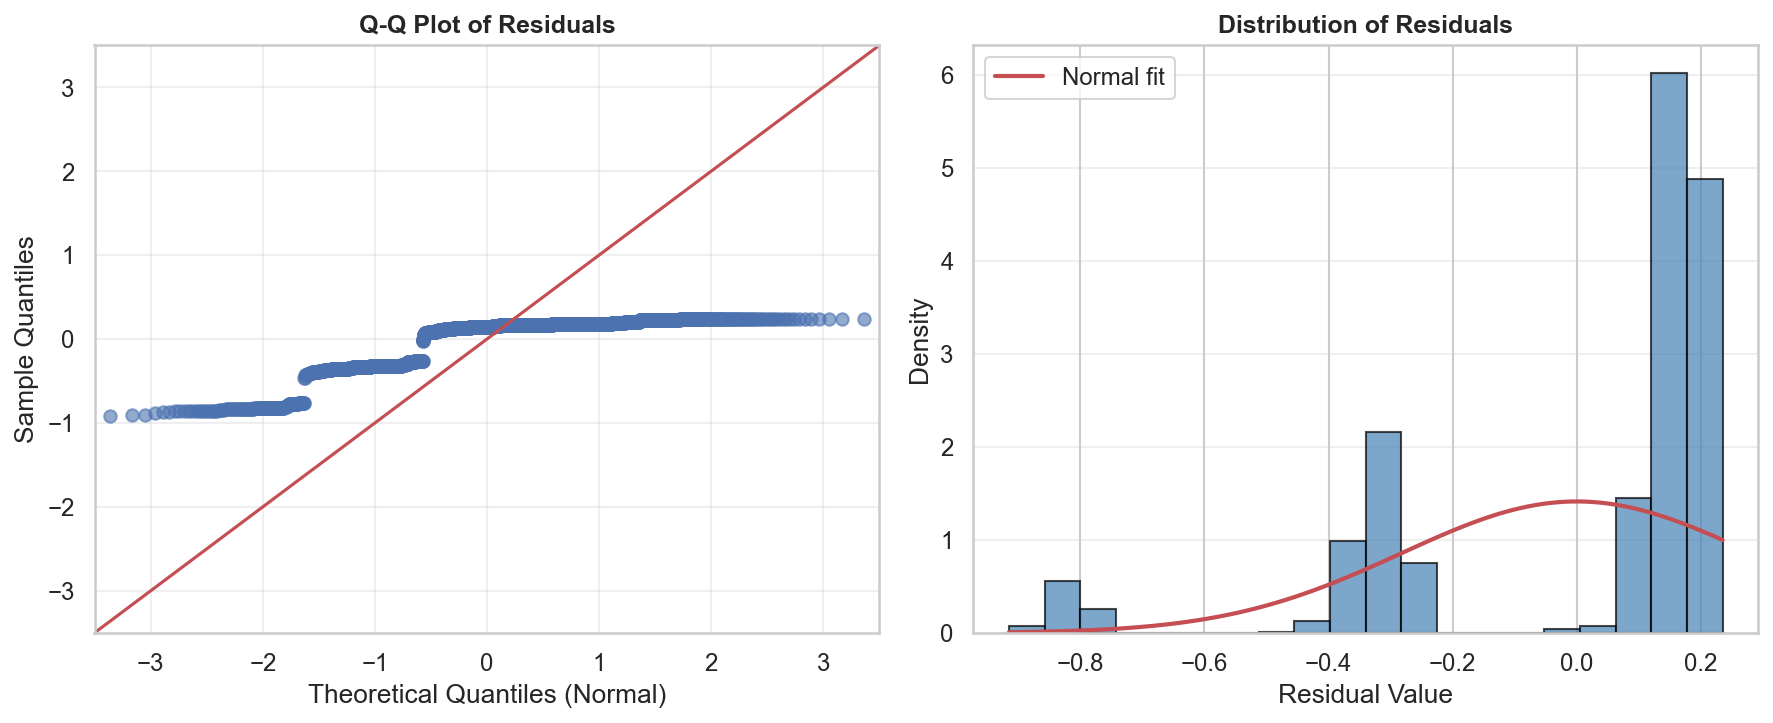

✓ Saved: plots/H4a_normality_check.png

HOW TO INTERPRET NORMALITY DIAGNOSTICS

Q-Q Plot:
  → Points close to the diagonal line → Normal distribution ✓
  → Points deviate, especially at tails → Non-normal (heavy tails, skew)

Histogram:
  → Bell-curve shape overlaid with "normal fit" (red line)
  → Good overlap → Normality ✓
  → Bimodal, skewed, or heavy tails → Departure from normality

Statistical Tests:
  → Shapiro-Wilk: most powerful for small-moderate samples
  → Anderson-Darling: sensitive to tails
  → K-S: less powerful but parameter-free

Decision Rule:
  • If all tests agree (p > .05) → Safe to use parametric tests ✓
  • If VISUAL diagnostics show mild deviation but N is large (> 50) 
    → ANOVA is robust; proceed with parametric tests
  • If multiple tests significant AND visuals show severe departure
    → Use non-parametric alternatives (Kruskal-Wallis, bootstrapping)



In [89]:
# ── VISUAL DIAGNOSTICS: Q-Q Plot & Histogram ──
print("\nGenerating visual diagnostics...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q Plot
sm.qqplot(residuals, line='45', ax=axes[0], markersize=6, alpha=0.6)
axes[0].set_title("Q-Q Plot of Residuals", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Theoretical Quantiles (Normal)")
axes[0].set_ylabel("Sample Quantiles")
axes[0].grid(True, alpha=0.3)

# Histogram with normal curve overlay
axes[1].hist(residuals, bins=20, density=True, alpha=0.7, color='steelblue', edgecolor='black')
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal fit')
axes[1].set_title("Distribution of Residuals", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Residual Value")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "H4a_normality_check.png"), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: plots/H4a_normality_check.png")

# ── INTERPRETATION GUIDE ──
print("\n" + "=" * 80)
print("HOW TO INTERPRET NORMALITY DIAGNOSTICS")
print("=" * 80)

print("""
Q-Q Plot:
  → Points close to the diagonal line → Normal distribution ✓
  → Points deviate, especially at tails → Non-normal (heavy tails, skew)
  
Histogram:
  → Bell-curve shape overlaid with "normal fit" (red line)
  → Good overlap → Normality ✓
  → Bimodal, skewed, or heavy tails → Departure from normality

Statistical Tests:
  → Shapiro-Wilk: most powerful for small-moderate samples
  → Anderson-Darling: sensitive to tails
  → K-S: less powerful but parameter-free
  
Decision Rule:
  • If all tests agree (p > .05) → Safe to use parametric tests ✓
  • If VISUAL diagnostics show mild deviation but N is large (> 50) 
    → ANOVA is robust; proceed with parametric tests
  • If multiple tests significant AND visuals show severe departure
    → Use non-parametric alternatives (Kruskal-Wallis, bootstrapping)
""")

print("=" * 80)

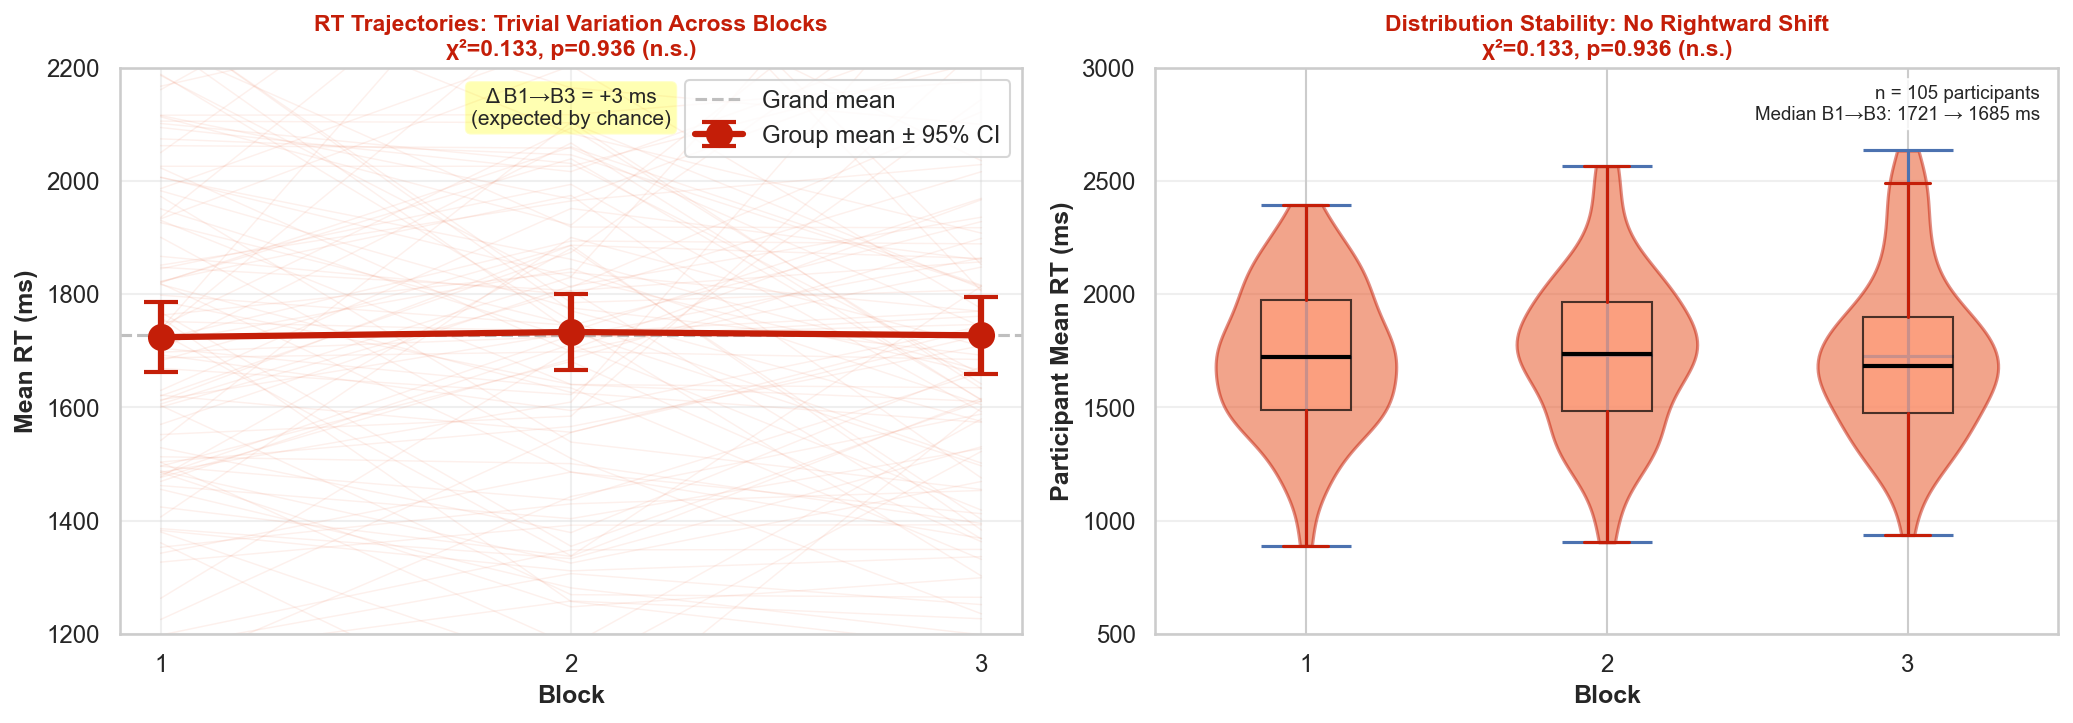

✓ Saved: plots/h2_null_effect.png

  → Individual trajectories (left) show random scatter, no systematic trend
  → Distribution shapes (right) highly similar across blocks
  → Kolmogorov-Smirnov test (KS): comparing Block 1 vs Block 3 distributions...
      KS statistic = 0.0762, p = 0.9227 (n.s.) → Distributions indistinguishable


In [92]:
# ── H2 Visual Evidence: 2 Plots Showing Null Effect ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─ PLOT 1: Line plot with individual trajectories + group mean ─────
ax = axes[0]
rt_by_block = rt_complete.groupby(["participant_ID", "block"])["mean_rt"].mean().reset_index()
for pid in rt_by_block["participant_ID"].unique():
    p_data = rt_by_block[rt_by_block["participant_ID"] == pid].sort_values("block")
    ax.plot(p_data["block"], p_data["mean_rt"], 
            color="#E64A19", alpha=0.08, linewidth=0.7, zorder=1)

# Group mean with CI
desc_rt = rt_complete.groupby("block")["mean_rt"].agg(mean="mean", sem="sem").reset_index()
ax.errorbar(desc_rt["block"], desc_rt["mean"], 
            yerr=desc_rt["sem"]*1.96, 
            marker="o", markersize=12, color="#C41E08", linewidth=3, 
            capsize=8, capthick=2, zorder=3, label="Group mean ± 95% CI")

ax.axhline(desc_rt["mean"].mean(), color="gray", linestyle="--", 
           alpha=0.5, linewidth=1.5, label="Grand mean")
ax.set_xticks([1, 2, 3])
ax.set_xlabel("Block", fontsize=12, fontweight="bold")
ax.set_ylabel("Mean RT (ms)", fontsize=12, fontweight="bold")
ax.set_title("RT Trajectories: Trivial Variation Across Blocks\nχ²=0.133, p=0.936 (n.s.)", 
             fontsize=11, fontweight="bold", color="#C41E08")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_ylim([1200, 2200])

# Add annotation
ax.text(2, 2100, "Δ B1→B3 = +3 ms\n(expected by chance)", 
        ha="center", fontsize=10, bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.3))

# ─ PLOT 2: Violin + box plot showing no compression across blocks ─────────────
ax = axes[1]
positions = [1, 2, 3]
distributions = [rt_complete[rt_complete["block"]==b]["mean_rt"].dropna().values for b in [1,2,3]]

parts = ax.violinplot(distributions, positions=positions, widths=0.6,
                       showmeans=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor("#E64A19")
    pc.set_alpha(0.5)
    pc.set_edgecolor("#C41E08")
    pc.set_linewidth(1.5)

# Overlay box plot for reference
bp = ax.boxplot(distributions, positions=positions, widths=0.3,
                patch_artist=True, showfliers=False,
                boxprops=dict(facecolor="#FF9D7B", alpha=0.7),
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(color="#C41E08", linewidth=1.5),
                capprops=dict(color="#C41E08", linewidth=1.5))

ax.set_xticks([1, 2, 3])
ax.set_xlabel("Block", fontsize=12, fontweight="bold")
ax.set_ylabel("Participant Mean RT (ms)", fontsize=12, fontweight="bold")
ax.set_title("Distribution Stability: No Rightward Shift\nχ²=0.133, p=0.936 (n.s.)", 
             fontsize=11, fontweight="bold", color="#C41E08")
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim([500, 3000])

# Add stats as text
stats_text = f"n = {len(rt_complete['participant_ID'].unique())} participants\nMedian B1→B3: {np.median(distributions[0]):.0f} → {np.median(distributions[2]):.0f} ms"
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        ha="right", va="top", fontsize=9, 
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/h2_null_effect.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Saved: plots/h2_null_effect.png")
print(f"\n  → Individual trajectories (left) show random scatter, no systematic trend")
print(f"  → Distribution shapes (right) highly similar across blocks")
print(f"  → Kolmogorov-Smirnov test (KS): comparing Block 1 vs Block 3 distributions...")

from scipy.stats import ks_2samp
ks_stat, ks_p = ks_2samp(distributions[0], distributions[2])
print(f"      KS statistic = {ks_stat:.4f}, p = {ks_p:.4f} (n.s.) → Distributions indistinguishable")